# CREDENCE — Credit Risk Edge: Analytics, Intelligence
## Análise de Risco de Crédito | Lending Club Loan Data (2007–2015)

> **Versão em português** — nomes de variáveis, funções e colunas traduzidos.
> Mantidos em inglês apenas: `grade`/`sub_grade`/`dti` (jargão técnico consagrado)
> e os **valores de dados** do CSV (`'Fully Paid'`, `'Verified'`, etc.), que precisam
> bater com o arquivo original.

**Tese central:** O grade é um proxy imperfeito de risco. O verdadeiro driver de inadimplência não é o grade isoladamente,
mas a combinação de prazo longo + DTI elevado + finalidade de alto risco.
Dentro do Grade C, essa combinação pode atingir taxa de inadimplência comparável ao Grade F.

---

## Seção 1 — Contexto e Setup

### Por que filtramos `status_emprestimo`?

O dataset contém empréstimos com desfecho desconhecido (`Current`, `In Grace Period`, `Late`).
Incluí-los na análise contaminaria a taxa base de inadimplência — estamos observando um snapshot
de contratos ainda em andamento, não seu resultado final.

**Regra de classificação:**
- `inadimplente = 1` → Charged Off, Default (e variantes "Does not meet credit policy")
- `inadimplente = 0` → Fully Paid (e variantes)
- **Excluídos:** Current, In Grace Period, Late (16–30d), Late (31–120d), Issued


In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from scipy import stats
from scipy.stats import chi2_contingency, norm
import statsmodels.api as sm
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
import missingno as msno

# Estilo global
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (12, 5)

SEMENTE = 42
np.random.seed(SEMENTE)
print('✓ Imports OK')


✓ Imports OK


In [2]:
# ── Carregar dados ──────────────────────────────
# Nomes ORIGINAIS do CSV (usados no usecols) e o mapa de tradução de colunas
COLUNAS_CSV = [
    'loan_amnt', 'int_rate', 'grade', 'sub_grade', 'annual_inc', 'dti',
    'purpose', 'term', 'home_ownership', 'emp_length', 'verification_status',
    'issue_d', 'loan_status', 'installment', 'addr_state', 'revol_util', 'total_acc'
]

MAPA_COLUNAS = {
    'loan_amnt': 'valor_emprestimo', 'int_rate': 'taxa_juros',
    'grade': 'grade', 'sub_grade': 'sub_grade', 'annual_inc': 'renda_anual',
    'dti': 'dti', 'purpose': 'finalidade', 'term': 'prazo',
    'home_ownership': 'tipo_moradia', 'emp_length': 'tempo_emprego',
    'verification_status': 'status_verificacao', 'issue_d': 'data_emissao',
    'loan_status': 'status_emprestimo', 'installment': 'parcela',
    'addr_state': 'estado', 'revol_util': 'util_rotativo', 'total_acc': 'total_contas'
}
COLUNAS = list(MAPA_COLUNAS.values())  # nomes traduzidos

df_bruto = pd.read_csv('../data/raw/loan.csv', usecols=COLUNAS_CSV, low_memory=False)
df_bruto = df_bruto.rename(columns=MAPA_COLUNAS)
print(f'Dataset bruto: {df_bruto.shape[0]:,} linhas × {df_bruto.shape[1]} colunas')

# ── Filtrar alvo ───────────────────────────────
STATUS_PAGO         = ['Fully Paid', 'Does not meet the credit policy. Status:Fully Paid']
STATUS_INADIMPLENTE = ['Charged Off', 'Default',
                       'Does not meet the credit policy. Status:Charged Off']

mascara = df_bruto['status_emprestimo'].isin(STATUS_PAGO + STATUS_INADIMPLENTE)
df = df_bruto[mascara].copy()
print(f'Dataset modelável: {len(df):,} linhas  ({len(df)/len(df_bruto)*100:.1f}% do total)')
print(f'Excluídos (desfecho desconhecido): {(~mascara).sum():,} registros')

# ── inadimplente ─────────────────────────────
df['inadimplente'] = df['status_emprestimo'].isin(STATUS_INADIMPLENTE).astype(int)
print(f"\nTaxa de inadimplência base: {df['inadimplente'].mean()*100:.1f}%")
print(df['inadimplente'].value_counts().rename({0:'Fully Paid', 1:'Charged Off/Default'}))


Dataset bruto: 2,260,668 linhas × 17 colunas


Dataset modelável: 1,306,387 linhas  (57.8% do total)
Excluídos (desfecho desconhecido): 954,281 registros

Taxa de inadimplência base: 20.1%
inadimplente
Fully Paid             1043940
Charged Off/Default     262447
Name: count, dtype: int64


In [3]:
# ── Tratamentos padrão ─────────────────────────

# taxa_juros: garantir float (algumas versões do dataset vêm com %)
df['taxa_juros'] = pd.to_numeric(
    df['taxa_juros'].astype(str).str.replace('%', '').str.strip(), errors='coerce'
)

# prazo: " 36 months" → 36
df['prazo'] = df['prazo'].astype(str).str.extract(r'(\d+)').astype(float).astype('Int64')

# tempo_emprego: "10+ years" → 10, "< 1 year" → 0
def converter_tempo_emprego(valor):
    if pd.isna(valor): return np.nan
    valor = str(valor).strip()
    if valor == '10+ years': return 10
    if valor == '< 1 year':  return 0
    digitos = ''.join(filter(str.isdigit, valor))
    return int(digitos) if digitos else np.nan

df['tempo_emprego'] = df['tempo_emprego'].apply(converter_tempo_emprego)

# data_emissao: "Dec-2018" → datetime → ano e mês
df['data_emissao'] = pd.to_datetime(df['data_emissao'], format='%b-%Y', errors='coerce')
df['ano_emissao']  = df['data_emissao'].dt.year.astype('Int64')
df['mes_emissao']  = df['data_emissao'].dt.month.astype('Int64')

# renda_anual: winsorizar p99 (outliers até $5M distorcem visualizações)
P99_RENDA = df['renda_anual'].quantile(0.99)
df['renda_anual_w'] = df['renda_anual'].clip(upper=P99_RENDA)

print('Tratamentos aplicados.')
print(f'renda_anual winsorizada no p99 = ${P99_RENDA:,.0f}')
print(f'\nShape final: {df.shape}')
print(f'Período: {df["ano_emissao"].min()} – {df["ano_emissao"].max()}')


Tratamentos aplicados.
renda_anual winsorizada no p99 = $250,000

Shape final: (1306387, 21)
Período: 2007 – 2018


In [4]:
# ── Visão geral de valores faltantes (colunas-chave) ─────
faltantes = df[COLUNAS].isnull().sum().sort_values(ascending=False)
faltantes_pct = (faltantes / len(df) * 100).round(2)
faltantes_df = pd.DataFrame({'faltantes_n': faltantes, 'faltantes_%': faltantes_pct})
faltantes_df = faltantes_df[faltantes_df['faltantes_n'] > 0]
print('=== Valores faltantes (apenas colunas com nulos) ===')
print(faltantes_df)


=== Valores faltantes (apenas colunas com nulos) ===
               faltantes_n  faltantes_%
tempo_emprego        75491         5.78
util_rotativo          850         0.07
dti                    312         0.02
total_contas            29         0.00
renda_anual              4         0.00


---
## Seção 2 — Análise Exploratória (EDA)

Antes de qualquer modelagem, precisamos entender as distribuições e identificar padrões visuais.
A EDA responde três perguntas:
1. **Quem** toma empréstimos? (perfil socioeconômico)
2. **Por quê** tomam? (finalidade e prazo)
3. **Quem não paga?** (taxa de inadimplência por segmento)


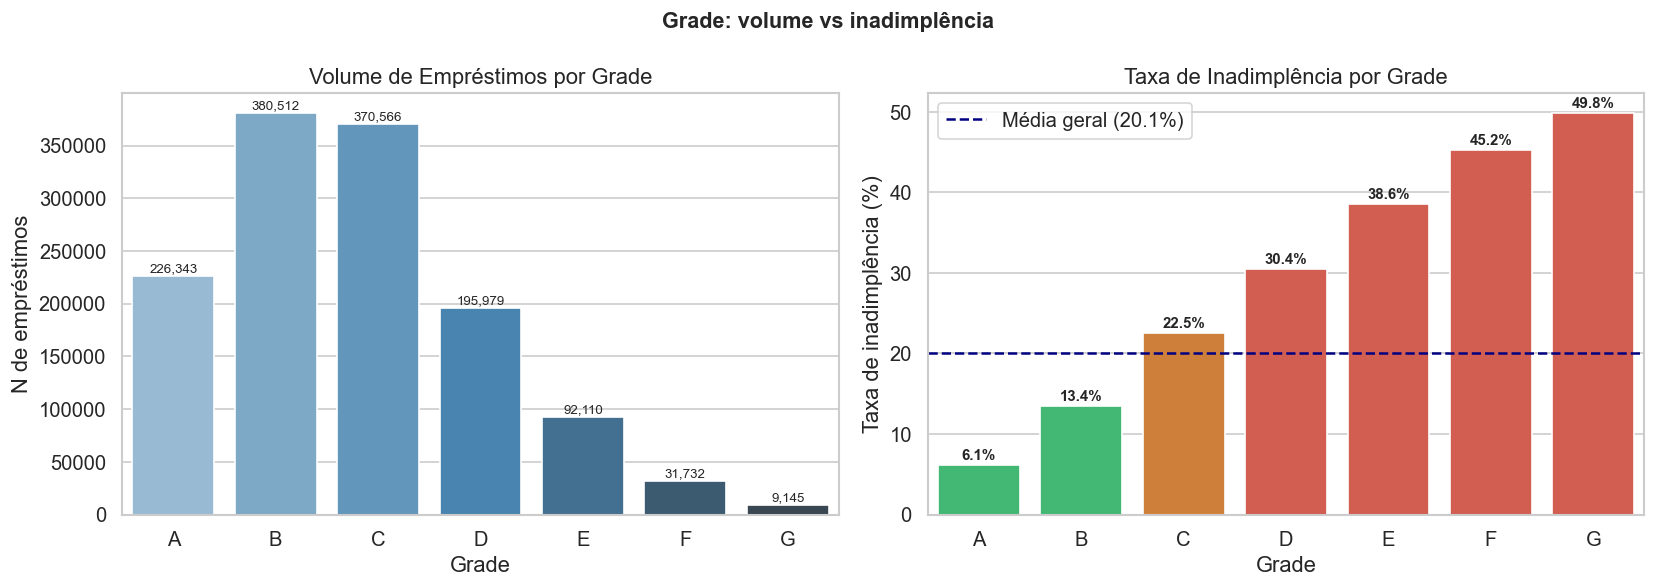

grade  n_emprestimos  taxa_inad_pct
    A         226343       6.086338
    B         380512      13.447145
    C         370566      22.511240
    D         195979      30.434894
    E          92110      38.569102
    F          31732      45.247699
    G           9145      49.797704


In [5]:
# ── 2.1 Taxa de inadimplência por Grade ───────────
stats_grade = (
    df.groupby('grade')
    .agg(n_emprestimos=('inadimplente','count'), taxa_inad=('inadimplente','mean'))
    .reset_index()
)
stats_grade['taxa_inad_pct'] = stats_grade['taxa_inad'] * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Volume por grade
sns.barplot(data=stats_grade, x='grade', y='n_emprestimos', palette='Blues_d', ax=axes[0])
axes[0].set_title('Volume de Empréstimos por Grade')
axes[0].set_ylabel('N de empréstimos')
axes[0].set_xlabel('Grade')
for barra, n in zip(axes[0].patches, stats_grade['n_emprestimos']):
    axes[0].text(barra.get_x() + barra.get_width()/2, barra.get_height() + 1000,
                 f'{n:,}', ha='center', va='bottom', fontsize=8)

# Taxa de inadimplência por grade
cores = ['#2ecc71' if r < 15 else '#e67e22' if r < 30 else '#e74c3c'
         for r in stats_grade['taxa_inad_pct']]
sns.barplot(data=stats_grade, x='grade', y='taxa_inad_pct', palette=cores, ax=axes[1])
axes[1].axhline(df['inadimplente'].mean()*100, color='navy', linestyle='--', linewidth=1.5,
                label=f'Média geral ({df["inadimplente"].mean()*100:.1f}%)')
axes[1].set_title('Taxa de Inadimplência por Grade')
axes[1].set_ylabel('Taxa de inadimplência (%)')
axes[1].set_xlabel('Grade')
axes[1].legend()
for barra, taxa in zip(axes[1].patches, stats_grade['taxa_inad_pct']):
    axes[1].text(barra.get_x() + barra.get_width()/2, barra.get_height() + 0.3,
                 f'{taxa:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.suptitle('Grade: volume vs inadimplência', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../assets/01_grade_default.png', bbox_inches='tight')
plt.show()
print(stats_grade[['grade','n_emprestimos','taxa_inad_pct']].to_string(index=False))


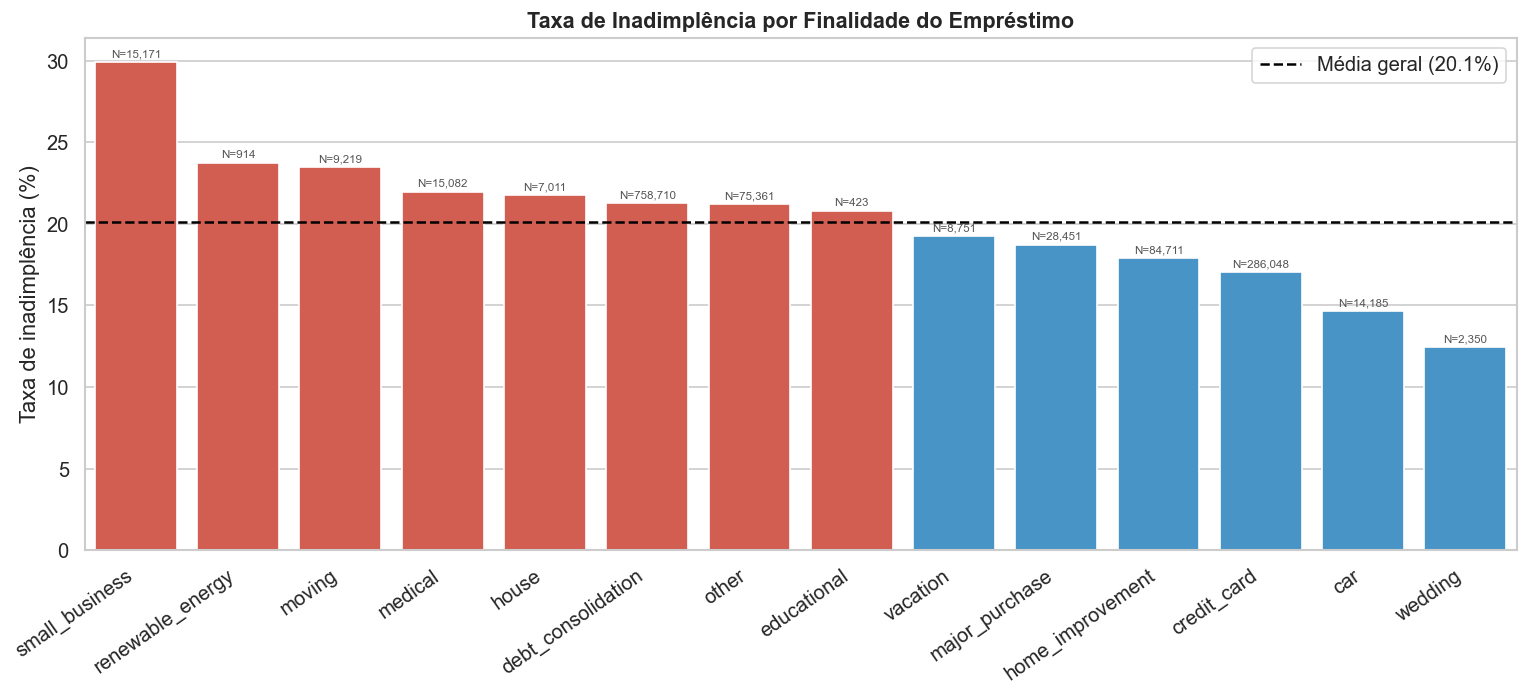

In [6]:
# ── 2.2 Taxa de inadimplência por Finalidade ────────
stats_finalidade = (
    df.groupby('finalidade')
    .agg(n_emprestimos=('inadimplente','count'), taxa_inad=('inadimplente','mean'))
    .reset_index()
    .sort_values('taxa_inad', ascending=False)
)
stats_finalidade['taxa_inad_pct'] = stats_finalidade['taxa_inad'] * 100
taxa_media = df['inadimplente'].mean() * 100

fig, ax = plt.subplots(figsize=(13, 6))
barras = sns.barplot(data=stats_finalidade, x='finalidade', y='taxa_inad_pct',
                     palette=['#e74c3c' if r > taxa_media else '#3498db'
                              for r in stats_finalidade['taxa_inad_pct']], ax=ax)
ax.axhline(taxa_media, color='black', linestyle='--', linewidth=1.5,
           label=f'Média geral ({taxa_media:.1f}%)')
ax.set_title('Taxa de Inadimplência por Finalidade do Empréstimo', fontsize=13, fontweight='bold')
ax.set_ylabel('Taxa de inadimplência (%)')
ax.set_xlabel('')
ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha='right')
ax.legend()

for barra, linha in zip(ax.patches, stats_finalidade.itertuples()):
    ax.text(barra.get_x() + barra.get_width()/2, barra.get_height() + 0.2,
            f'N={linha.n_emprestimos:,}', ha='center', va='bottom', fontsize=7, color='#555')

plt.tight_layout()
plt.savefig('../assets/02_purpose_default.png', bbox_inches='tight')
plt.show()


Prazo × Taxa de inadimplência:
 prazo  n_emprestimos  taxa_inad  taxa_inad_pct
    36         991212   0.161235      16.123493
    60         315175   0.325625      32.562545


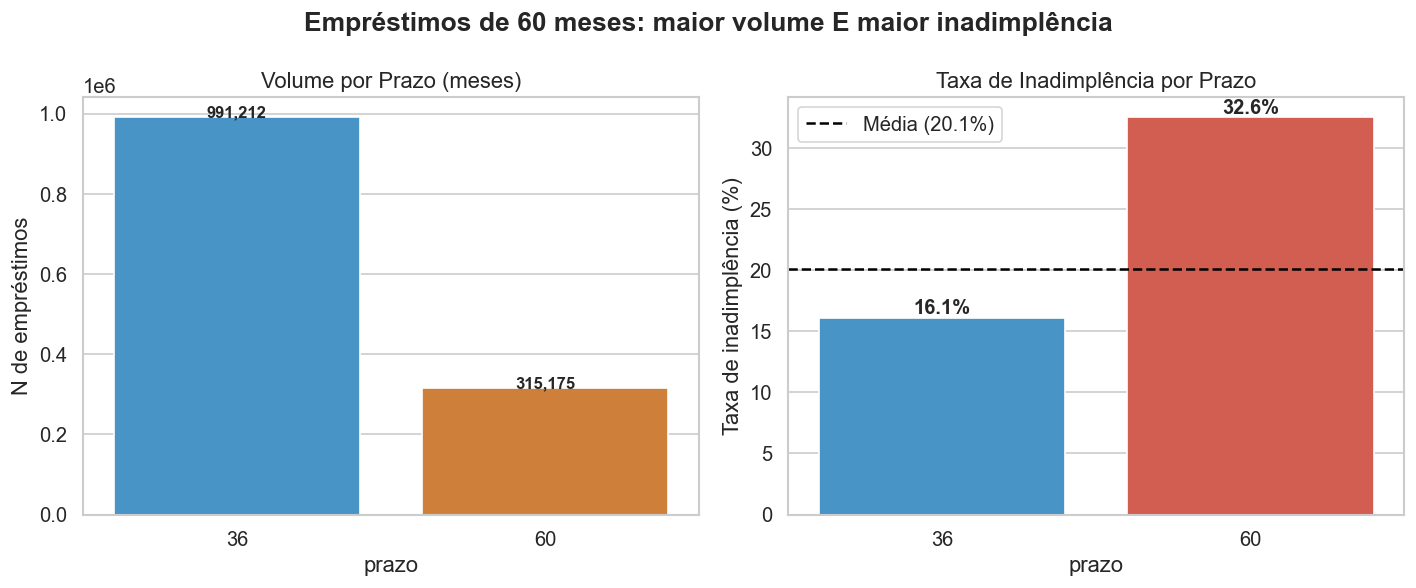

In [7]:
# ── 2.3 Prazo: 36 vs 60 meses ────────────────
stats_prazo = (
    df.groupby('prazo')
    .agg(n_emprestimos=('inadimplente','count'), taxa_inad=('inadimplente','mean'))
    .reset_index()
)
stats_prazo['taxa_inad_pct'] = stats_prazo['taxa_inad'] * 100
print('Prazo × Taxa de inadimplência:')
print(stats_prazo.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.barplot(data=stats_prazo, x='prazo', y='n_emprestimos',
            palette=['#3498db','#e67e22'], ax=axes[0])
axes[0].set_title('Volume por Prazo (meses)')
axes[0].set_ylabel('N de empréstimos')
for barra, n in zip(axes[0].patches, stats_prazo['n_emprestimos']):
    axes[0].text(barra.get_x() + barra.get_width()/2, barra.get_height() + 500,
                 f'{n:,}', ha='center', fontsize=10, fontweight='bold')

sns.barplot(data=stats_prazo, x='prazo', y='taxa_inad_pct',
            palette=['#3498db','#e74c3c'], ax=axes[1])
axes[1].axhline(taxa_media, color='black', linestyle='--', label=f'Média ({taxa_media:.1f}%)')
axes[1].set_title('Taxa de Inadimplência por Prazo')
axes[1].set_ylabel('Taxa de inadimplência (%)')
axes[1].legend()
for barra, taxa in zip(axes[1].patches, stats_prazo['taxa_inad_pct']):
    axes[1].text(barra.get_x() + barra.get_width()/2, barra.get_height() + 0.3,
                 f'{taxa:.1f}%', ha='center', fontsize=12, fontweight='bold')

plt.suptitle('Empréstimos de 60 meses: maior volume E maior inadimplência', fontweight='bold')
plt.tight_layout()
plt.savefig('../assets/03_term_default.png', bbox_inches='tight')
plt.show()


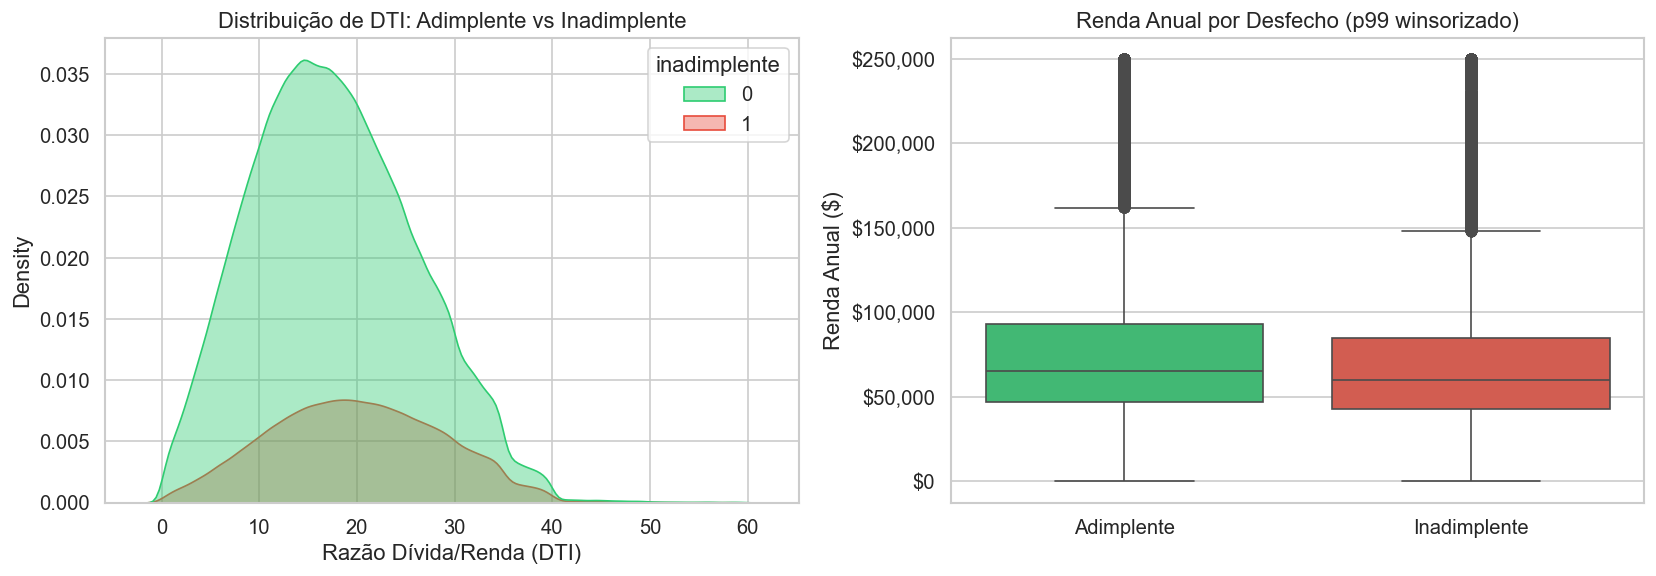

Renda mediana por desfecho:
inadimplente
Adimplente      65000.0
Inadimplente    60000.0
Name: renda_anual, dtype: float64

DTI mediano por desfecho:
inadimplente
Adimplente      17.09
Inadimplente    19.76
Name: dti, dtype: float64


In [8]:
# ── 2.4 Perfil socioeconômico: DTI e Renda Anual ─────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# DTI por inadimplente
dti_limitado = df[df['dti'] <= 60].copy()
sns.kdeplot(data=dti_limitado, x='dti', hue='inadimplente',
            palette={0:'#2ecc71', 1:'#e74c3c'}, fill=True, alpha=0.4, ax=axes[0])
axes[0].set_title('Distribuição de DTI: Adimplente vs Inadimplente')
axes[0].set_xlabel('Razão Dívida/Renda (DTI)')

# Renda anual (winsorizada) por inadimplente
sns.boxplot(data=df, x='inadimplente', y='renda_anual_w', hue='inadimplente',
            palette={0:'#2ecc71', 1:'#e74c3c'}, legend=False, ax=axes[1])
axes[1].set_title('Renda Anual por Desfecho (p99 winsorizado)')
axes[1].set_xlabel('')
axes[1].set_xticklabels(['Adimplente', 'Inadimplente'])
axes[1].set_ylabel('Renda Anual ($)')
axes[1].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x:,.0f}'))

plt.tight_layout()
plt.savefig('../assets/04_socioeconomico.png', bbox_inches='tight')
plt.show()

print('Renda mediana por desfecho:')
print(df.groupby('inadimplente')['renda_anual'].median().rename({0:'Adimplente', 1:'Inadimplente'}))
print('\nDTI mediano por desfecho:')
print(df.groupby('inadimplente')['dti'].median().rename({0:'Adimplente', 1:'Inadimplente'}))


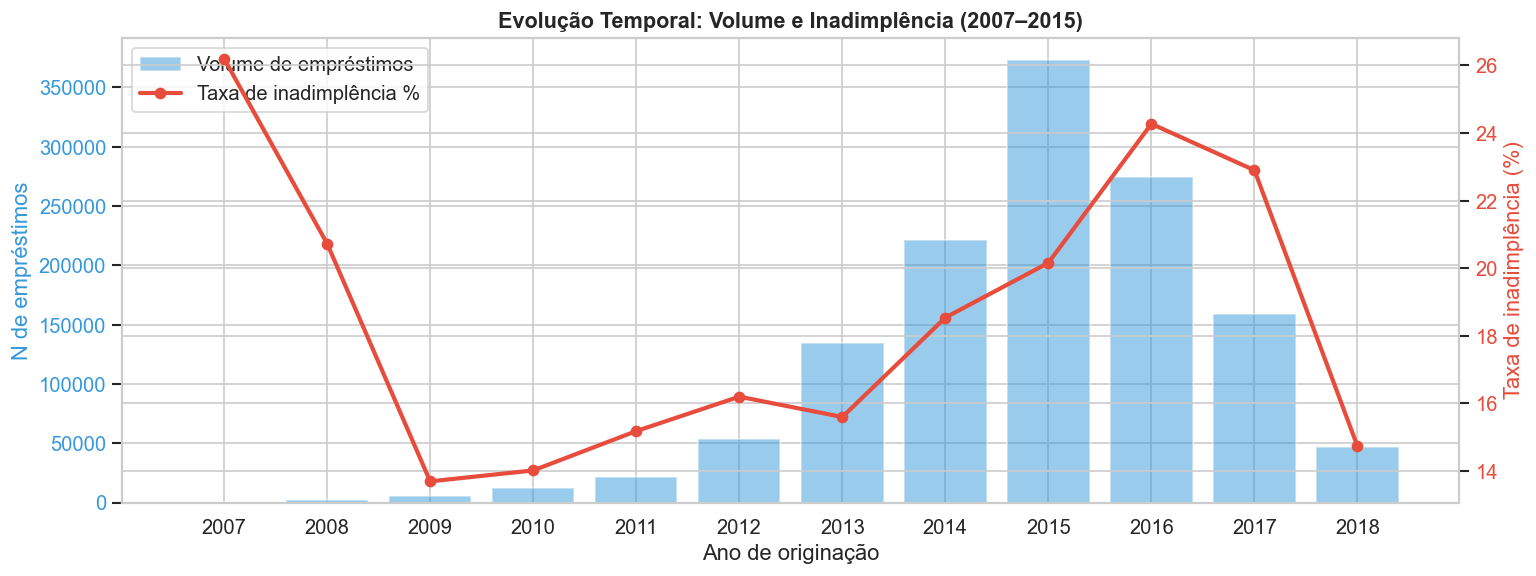

 ano_emissao  n_emprestimos  taxa_inad_pct
        2007            603      26.202322
        2008           2393      20.727121
        2009           5281      13.690589
        2010          12537      14.014517
        2011          21721      15.178859
        2012          53367      16.197275
        2013         134793      15.595765
        2014         221468      18.538118
        2015         373412      20.158699
        2016         274711      24.272417
        2017         158910      22.899125
        2018          47191      14.729504


In [9]:
# ── 2.5 Evolução temporal da inadimplência ─────────
temporal = (
    df.groupby('ano_emissao')
    .agg(n_emprestimos=('inadimplente','count'), taxa_inad=('inadimplente','mean'))
    .reset_index()
    .dropna(subset=['ano_emissao'])
)
temporal['taxa_inad_pct'] = temporal['taxa_inad'] * 100

fig, ax1 = plt.subplots(figsize=(13, 5))
ax2 = ax1.twinx()

ax1.bar(temporal['ano_emissao'], temporal['n_emprestimos'],
        color='#3498db', alpha=0.5, label='Volume de empréstimos')
ax1.set_ylabel('N de empréstimos', color='#3498db')
ax1.tick_params(axis='y', labelcolor='#3498db')

ax2.plot(temporal['ano_emissao'], temporal['taxa_inad_pct'],
         color='#e74c3c', marker='o', linewidth=2.5, label='Taxa de inadimplência %')
ax2.set_ylabel('Taxa de inadimplência (%)', color='#e74c3c')
ax2.tick_params(axis='y', labelcolor='#e74c3c')

ax1.set_title('Evolução Temporal: Volume e Inadimplência (2007–2015)', fontsize=13, fontweight='bold')
ax1.set_xlabel('Ano de originação')
ax1.set_xticks(temporal['ano_emissao'].dropna().astype(int))

linhas1, rotulos1 = ax1.get_legend_handles_labels()
linhas2, rotulos2 = ax2.get_legend_handles_labels()
ax1.legend(linhas1 + linhas2, rotulos1 + rotulos2, loc='upper left')

plt.tight_layout()
plt.savefig('../assets/05_temporal.png', bbox_inches='tight')
plt.show()
print(temporal[['ano_emissao','n_emprestimos','taxa_inad_pct']].to_string(index=False))


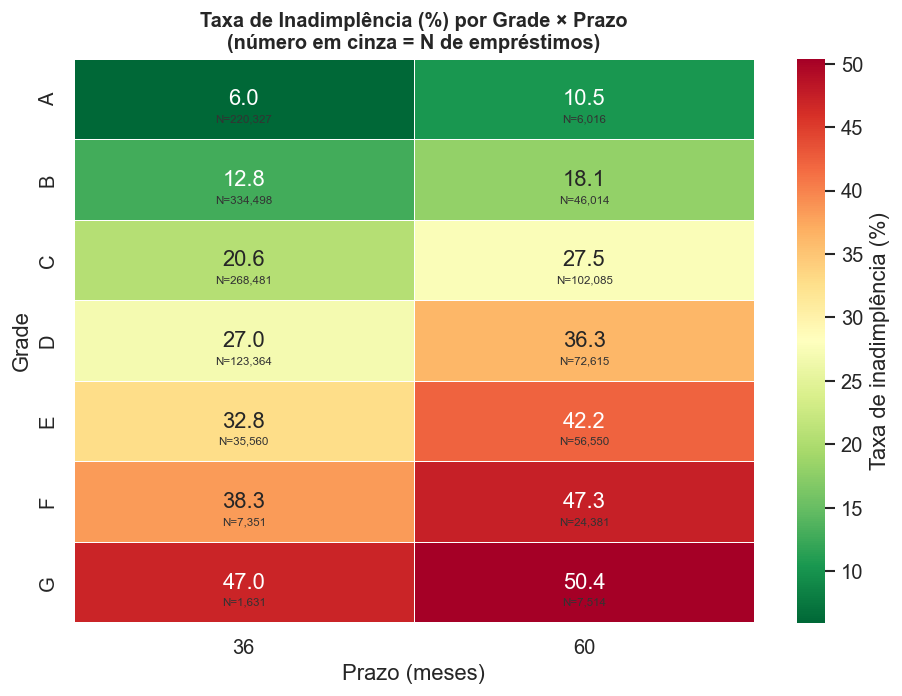

In [10]:
# ── 2.6 Heatmap: Grade × Prazo (taxa de inadimplência) ───
calor = df.groupby(['grade','prazo'])['inadimplente'].agg(['mean','count']).reset_index()
calor.columns = ['grade','prazo','taxa_inad','n']
pivot_calor = calor.pivot(index='grade', columns='prazo', values='taxa_inad') * 100
pivot_n     = calor.pivot(index='grade', columns='prazo', values='n')

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(pivot_calor, annot=True, fmt='.1f', cmap='RdYlGn_r',
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Taxa de inadimplência (%)'})

# Anotar N
for i, grade in enumerate(pivot_calor.index):
    for j, prazo in enumerate(pivot_calor.columns):
        n = pivot_n.loc[grade, prazo] if prazo in pivot_n.columns else 0
        ax.text(j + 0.5, i + 0.75, f'N={n:,}', ha='center', va='center',
                fontsize=7, color='#333')

ax.set_title('Taxa de Inadimplência (%) por Grade × Prazo\n(número em cinza = N de empréstimos)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Prazo (meses)')
ax.set_ylabel('Grade')
plt.tight_layout()
plt.savefig('../assets/06_heatmap_grade_term.png', bbox_inches='tight')
plt.show()


---
## Seção 2.7 — Mapa de Risco Geográfico

Geografia importa para risco de crédito por dois mecanismos distintos:

1. **Composição:** estados diferentes atraem perfis diferentes de borrower (mix de grades, finalidades, rendas).
2. **Efeito geográfico puro:** o mesmo perfil de borrower performa diferente em estados diferentes — drivers macro locais (desemprego, custo de vida, mercado imobiliário, ciclos econômicos regionais).

Política de crédito séria precisa **separar os dois**. Restringir crédito num estado só por composição é tratar sintoma; o que importa é o **excesso de inadimplência condicional ao perfil**.

Aplicamos uma **decomposição estilo Oaxaca-Blinder**:

```
inad_esperada(estado) = Σ_grade [ share_grade(estado) × taxa_inad_grade(nacional) ]
efeito_geográfico_puro = inad_realizada(estado) − inad_esperada(estado)
```

Se o "efeito puro" é positivo, o estado tem risco residual *além* do explicado pelo seu mix de borrowers — sinal de monitoramento elevado.

> **Nota regulatória (ECOA / Reg B):** `estado` não pode ser usado como hard cutoff de underwriting nos EUA — caracteriza *disparate impact*. Pode ser usado para **risk-based pricing** documentado e **caps de exposição** atuarialmente justificados. As recomendações da Seção 7 respeitam essa restrição.

---

### ⚠️ Limitação metodológica: por que UF e não ZIP code

A análise é feita no nível **estado (`estado`)** e não no nível ZIP code, apesar de o
dataset trazer a coluna `zip_code`. As razões são metodológicas e regulatórias:

1. **`zip_code` está incompleto por design.** O Lending Club mascara os ZIPs publicando apenas
   os **3 primeiros dígitos** (ex.: `100xx`, `941xx`) — anonimização para proteger a privacidade
   do borrower. Não dá para identificar bairro, apenas a região postal ampla (≈ região
   metropolitana). Não é o mesmo que ZIP completo (5 dígitos) que um banco usaria internamente.

2. **Granularidade vs N.** O ZIP-3 gera ~900 buckets (vs ~50 estados). Em uma carteira de
   1,3M de loans, isso significa ~1.400 loans por bucket *em média*, mas com cauda longa —
   30–40% dos ZIP-3s teriam que ser excluídos por `N < 500`. Acaba ficando mais ruidoso e
   menos acionável.

3. **Risco regulatório aumentado.** Quanto mais granular a geografia, mais perto se chega da
   fronteira de *disparate impact* sob ECOA. UF é defensável como variável atuarial; ZIP-3
   já exige documentação adicional de *fair lending*. Para uma recomendação de política,
   UF é o nível "regulatoriamente seguro".

4. **Interpretabilidade de negócio.** "Cap de exposição em CA" é uma decisão executável e
   vai a comitê de crédito. "Cap em ZIP-3 941xx" não é uma narrativa que se sustenta numa
   reunião de política de crédito.

**Limitação aceita:** UF esconde heterogeneidade intra-estado relevante — Beverly Hills e
Compton estão ambos em "CA", com perfis de risco completamente diferentes. Em produção,
um banco usaria **ZIP completo (5 dígitos) + mapeamento para MSA** (*Metropolitan Statistical
Area*) para capturar o mercado de trabalho local, que é o driver real de inadimplência. Esse
refinamento é trabalho fora do escopo do teste técnico — fica documentado aqui como próxima
iteração natural da análise.


In [11]:
# ── 2.7.1 Estatísticas brutas por estado ──────────
N_MIN_ESTADO = 500  # piso de confiabilidade — abaixo disso, intervalo é dominado por ruído

stats_geo = (
    df.groupby('estado')
      .agg(n_emprestimos=('inadimplente','count'),
           taxa_inad=('inadimplente','mean'),
           valor_medio=('valor_emprestimo','mean'),
           dti_medio=('dti','mean'),
           taxa_juros_media=('taxa_juros','mean'))
      .reset_index()
)
stats_geo['taxa_inad_pct'] = stats_geo['taxa_inad'] * 100
stats_geo_filt = stats_geo[stats_geo['n_emprestimos'] >= N_MIN_ESTADO].copy()

# IC 95% por estado (proporção)
stats_geo_filt['ep'] = np.sqrt(
    stats_geo_filt['taxa_inad'] * (1 - stats_geo_filt['taxa_inad']) / stats_geo_filt['n_emprestimos']
)
stats_geo_filt['ic_inf'] = (stats_geo_filt['taxa_inad'] - 1.96 * stats_geo_filt['ep']) * 100
stats_geo_filt['ic_sup'] = (stats_geo_filt['taxa_inad'] + 1.96 * stats_geo_filt['ep']) * 100

taxa_nacional = df['inadimplente'].mean() * 100
print(f'Estados retidos (N ≥ {N_MIN_ESTADO}): {len(stats_geo_filt)} de {len(stats_geo)}')
print(f'Taxa nacional: {taxa_nacional:.2f}%')
print(f'\nTop 5 piores (taxa de inadimplência bruta):')
print(stats_geo_filt.nlargest(5, 'taxa_inad_pct')[['estado','n_emprestimos','taxa_inad_pct','ic_inf','ic_sup']].to_string(index=False))
print(f'\nTop 5 melhores:')
print(stats_geo_filt.nsmallest(5, 'taxa_inad_pct')[['estado','n_emprestimos','taxa_inad_pct','ic_inf','ic_sup']].to_string(index=False))


Estados retidos (N ≥ 500): 50 de 51
Taxa nacional: 20.09%

Top 5 piores (taxa de inadimplência bruta):
estado  n_emprestimos  taxa_inad_pct    ic_inf    ic_sup
    MS           6323      26.237545 25.153185 27.321906
    NE           3428      25.466744 24.008275 26.925214
    AR           9723      24.190065 23.338853 25.041276
    AL          16162      23.740874 23.084875 24.396872
    OK          11863      23.703953 22.938674 24.469233

Top 5 melhores:
estado  n_emprestimos  taxa_inad_pct    ic_inf    ic_sup
    DC           3380      13.136095 11.997287 14.274903
    ME           1921      13.951067 12.401648 15.500486
    VT           2562      14.129586 12.780769 15.478403
    OR          15982      14.422475 13.877797 14.967154
    NH           6259      14.586995 13.712517 15.461472


In [12]:
# ── 2.7.2 Decomposição Oaxaca: efeito puro vs composição ─
# Taxa de inadimplência nacional por grade (benchmark)
taxa_grade_nacional = df.groupby('grade')['inadimplente'].mean()

# Para cada estado: share de cada grade × taxa nacional daquele grade
estado_grade = (
    df.groupby(['estado','grade']).size()
      .unstack(fill_value=0)
)
estado_grade_share = estado_grade.div(estado_grade.sum(axis=1), axis=0)

# inad_esperada = Σ share_estado(grade) × taxa_nacional(grade)
esperado = estado_grade_share.mul(taxa_grade_nacional, axis=1).sum(axis=1)
esperado_df = esperado.reset_index()
esperado_df.columns = ['estado','taxa_esperada']

geo_decomp = stats_geo_filt.merge(esperado_df, on='estado')
geo_decomp['taxa_esperada_pct'] = geo_decomp['taxa_esperada'] * 100
geo_decomp['efeito_geo_puro_pp'] = geo_decomp['taxa_inad_pct'] - geo_decomp['taxa_esperada_pct']

print('=== Top 5 estados com EFEITO GEOGRÁFICO PURO mais alto ===')
print('(inadimplência residual após controlar pelo mix de grade)')
print(geo_decomp.nlargest(5, 'efeito_geo_puro_pp')[
    ['estado','n_emprestimos','taxa_inad_pct','taxa_esperada_pct','efeito_geo_puro_pp']
].round(2).to_string(index=False))

print('\n=== Top 5 estados com EFEITO GEOGRÁFICO PURO mais baixo (melhores) ===')
print(geo_decomp.nsmallest(5, 'efeito_geo_puro_pp')[
    ['estado','n_emprestimos','taxa_inad_pct','taxa_esperada_pct','efeito_geo_puro_pp']
].round(2).to_string(index=False))


=== Top 5 estados com EFEITO GEOGRÁFICO PURO mais alto ===
(inadimplência residual após controlar pelo mix de grade)
estado  n_emprestimos  taxa_inad_pct  taxa_esperada_pct  efeito_geo_puro_pp
    MS           6323          26.24              21.23                5.00
    NE           3428          25.47              20.84                4.63
    AR           9723          24.19              20.64                3.55
    OK          11863          23.70              20.49                3.21
    LA          15046          23.40              20.34                3.06

=== Top 5 estados com EFEITO GEOGRÁFICO PURO mais baixo (melhores) ===
estado  n_emprestimos  taxa_inad_pct  taxa_esperada_pct  efeito_geo_puro_pp
    DC           3380          13.14              18.83               -5.70
    ME           1921          13.95              19.31               -5.36
    VT           2562          14.13              19.43               -5.30
    OR          15982          14.42              1

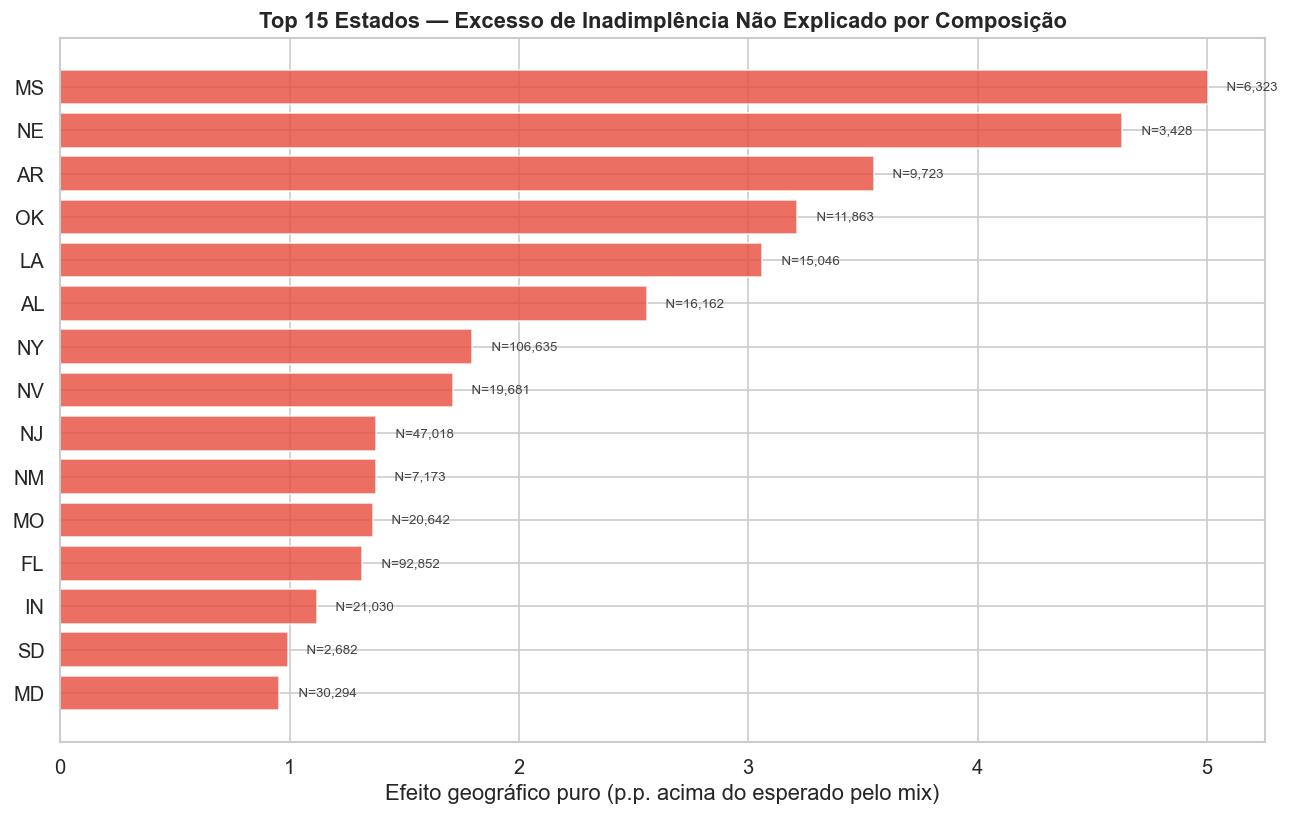

=== Estados ENGANOSOS — parecem ruins no bruto, mas o efeito puro é neutro/bom ===
(rank_bruto baixo = pior no bruto; rank_dif negativo = "exonerado" pelo controle de mix)
estado  taxa_inad_pct  taxa_esperada_pct  efeito_geo_puro_pp  rank_bruto  rank_puro
    HI          20.30              21.46               -1.16        23.0       31.0
    ND          20.85              21.04               -0.19        20.0       28.0
    TN          21.60              20.72                0.88        10.0       16.0
    DE          20.20              20.46               -0.26        24.0       29.0
    IN          21.64              20.52                1.12         9.0       13.0


In [13]:
# ── 2.7.3 Choropleths lado a lado: bruto vs efeito puro ─
# Mostra a diferença entre olhar o número cru e olhar o sinal acionável

fig_dual = make_subplots(
    rows=1, cols=2,
    specs=[[{'type': 'choropleth'}, {'type': 'choropleth'}]],
    subplot_titles=('(a) Taxa de inadimplência BRUTA por estado<br><sub>confunde composição com efeito local</sub>',
                    '(b) Efeito geográfico PURO<br><sub>após controlar pelo mix de grade — sinal acionável</sub>'),
    horizontal_spacing=0.05
)

# (a) Taxa de inadimplência bruta
fig_dual.add_trace(
    go.Choropleth(
        locations=geo_decomp['estado'],
        z=geo_decomp['taxa_inad_pct'],
        locationmode='USA-states',
        colorscale='Reds',
        zmin=geo_decomp['taxa_inad_pct'].min(),
        zmax=geo_decomp['taxa_inad_pct'].max(),
        colorbar=dict(title='%', x=0.46, len=0.8, thickness=12),
        hovertemplate='<b>%{location}</b><br>Inadimplência bruta: %{z:.2f}%<extra></extra>',
    ),
    row=1, col=1
)

# (b) Efeito geográfico puro
fig_dual.add_trace(
    go.Choropleth(
        locations=geo_decomp['estado'],
        z=geo_decomp['efeito_geo_puro_pp'],
        locationmode='USA-states',
        colorscale='RdBu_r',
        zmid=0,
        zmin=-3, zmax=3,
        colorbar=dict(title='p.p.', x=1.0, len=0.8, thickness=12),
        hovertemplate='<b>%{location}</b><br>Efeito puro: %{z:+.2f} p.p.<extra></extra>',
    ),
    row=1, col=2
)

fig_dual.update_geos(scope='usa', row=1, col=1)
fig_dual.update_geos(scope='usa', row=1, col=2)
fig_dual.update_layout(
    height=480,
    margin=dict(l=0, r=0, t=80, b=0),
    title_text='<b>Mapa de Risco Geográfico — duas leituras do mesmo dado</b>',
    title_x=0.5
)
fig_dual.show()
fig_dual.write_html('../assets/13_mapa_geo_dual.html')

# Ranking horizontal: piores 15 estados por efeito puro
piores15 = geo_decomp.nlargest(15, 'efeito_geo_puro_pp').sort_values('efeito_geo_puro_pp')
fig, ax = plt.subplots(figsize=(11, 7))
cores_geo = ['#e74c3c' if x > 0 else '#2ecc71' for x in piores15['efeito_geo_puro_pp']]
ax.barh(piores15['estado'], piores15['efeito_geo_puro_pp'], color=cores_geo, alpha=0.8)
ax.axvline(0, color='black', linewidth=1)
ax.set_xlabel('Efeito geográfico puro (p.p. acima do esperado pelo mix)')
ax.set_title('Top 15 Estados — Excesso de Inadimplência Não Explicado por Composição',
             fontweight='bold')
for i, (estado, val, n) in enumerate(zip(piores15['estado'],
                                          piores15['efeito_geo_puro_pp'],
                                          piores15['n_emprestimos'])):
    ax.text(val + (0.05 if val > 0 else -0.05), i, f'  N={n:,}',
            va='center', ha='left' if val > 0 else 'right', fontsize=8, color='#444')
plt.tight_layout()
plt.savefig('../assets/13b_ranking_geo_efeito_puro.png', bbox_inches='tight')
plt.show()

# Estados onde o bruto sugere "ruim" mas o efeito puro é neutro/bom
geo_decomp['rank_bruto'] = geo_decomp['taxa_inad_pct'].rank(ascending=False)
geo_decomp['rank_puro']  = geo_decomp['efeito_geo_puro_pp'].rank(ascending=False)
geo_decomp['rank_dif']   = geo_decomp['rank_bruto'] - geo_decomp['rank_puro']
print('=== Estados ENGANOSOS — parecem ruins no bruto, mas o efeito puro é neutro/bom ===')
print('(rank_bruto baixo = pior no bruto; rank_dif negativo = "exonerado" pelo controle de mix)')
print(geo_decomp.nsmallest(5, 'rank_dif')[
    ['estado','taxa_inad_pct','taxa_esperada_pct','efeito_geo_puro_pp','rank_bruto','rank_puro']
].round(2).to_string(index=False))


---
## Seção 2.8 — Renda × Verificação: um caso de viés de seleção

Esta seção começou com a hipótese de que renda autodeclarada **não-verificada** teria viés de
superdeclaração e, portanto, pior performance. **Os dados refutam a hipótese** — e o motivo é
metodologicamente importante.

### O que os dados mostram

Em **todas** as faixas de renda, empréstimos `Not Verified` têm a **menor** taxa de inadimplência
e `Verified` a **maior** — o oposto do esperado.

### Por que: `status_verificacao` é uma variável endógena

O Lending Club **não verificava a renda aleatoriamente**. A verificação era exigida com mais
frequência justamente para os pedidos que já exibiam sinais de risco. Portanto:

- `status_verificacao` é **consequência** de uma triagem de risco anterior do próprio LC —
  não uma causa independente.
- "Verificado" funciona como um *marcador* de que o LC já havia desconfiado daquele borrower.
- A correlação verificação → inadimplência é **viés de seleção**, não efeito causal.

Isso torna `status_verificacao` quase um vazamento (*leakage*) suave: carrega informação de
uma decisão downstream do LC. **Conclusão metodológica:** não se pode usar `status_verificacao`
como feature protetora num modelo, nem concluir que *tornar a verificação obrigatória* reduziria
risco — a relação observada é seleção, e mexer na política não move a causa.

> Por isso `status_verificacao` **não entra** na combinação tóxica da Seção 6.4 nem nas
> recomendações da Seção 7. É mantido apenas como variável descritiva no export do Looker.

**Faixas de renda usadas:** `<$40k`, `$40k-60k`, `$60k-100k`, `$100k-150k`, `>$150k`.


In [14]:
# ── 2.8.1 Faixas de renda × taxa de inadimplência ─────
df['faixa_renda'] = pd.cut(
    df['renda_anual'],
    bins=[0, 40_000, 60_000, 100_000, 150_000, np.inf],
    labels=['<$40k', '$40k-60k', '$60k-100k', '$100k-150k', '>$150k']
)

stats_renda = (
    df.groupby('faixa_renda', observed=True)
      .agg(n_emprestimos=('inadimplente','count'),
           taxa_inad=('inadimplente','mean'),
           dti_medio=('dti','mean'),
           valor_medio=('valor_emprestimo','mean'))
      .reset_index()
)
stats_renda['taxa_inad_pct'] = stats_renda['taxa_inad'] * 100
print('=== Taxa de inadimplência por faixa de renda ===')
print(stats_renda.round(2).to_string(index=False))

# Cruzamento com status_verificacao
renda_verif = (
    df.groupby(['faixa_renda','status_verificacao'], observed=True)['inadimplente']
      .agg(['mean','count'])
      .reset_index()
      .rename(columns={'mean':'taxa_inad','count':'n'})
)
renda_verif['taxa_inad_pct'] = renda_verif['taxa_inad'] * 100
renda_verif = renda_verif[renda_verif['n'] >= 500]

pivot_rv = renda_verif.pivot(index='faixa_renda', columns='status_verificacao',
                             values='taxa_inad_pct')
pivot_n_rv = renda_verif.pivot(index='faixa_renda', columns='status_verificacao', values='n')

print('\n=== Taxa de inadimplência (%) por Faixa de Renda × Verificação ===')
print(pivot_rv.round(2).to_string())
print('\nN por célula:')
print(pivot_n_rv.fillna(0).astype(int).to_string())


=== Taxa de inadimplência por faixa de renda ===
faixa_renda  n_emprestimos  taxa_inad  dti_medio  valor_medio  taxa_inad_pct
      <$40k         238463       0.24      20.76      8290.10          23.82
   $40k-60k         361835       0.22      19.37     11969.05          21.71
  $60k-100k         463858       0.19      17.80     16032.45          19.13
 $100k-150k         173441       0.16      15.78     19982.16          16.25
     >$150k          68484       0.15      12.90     23419.27          14.73



=== Taxa de inadimplência (%) por Faixa de Renda × Verificação ===
status_verificacao  Not Verified  Source Verified  Verified
faixa_renda                                                
<$40k                      18.27            24.83     28.02
$40k-60k                   15.76            23.33     26.19
$60k-100k                  13.57            20.24     23.38
$100k-150k                 11.28            17.35     18.97
>$150k                     10.68            15.30     15.74

N por célula:
status_verificacao  Not Verified  Source Verified  Verified
faixa_renda                                                
<$40k                      74859            84949     78655
$40k-60k                  117880           137062    106893
$60k-100k                 143655           178825    141378
$100k-150k                 46695            69475     57271
>$150k                     10669            33709     24106


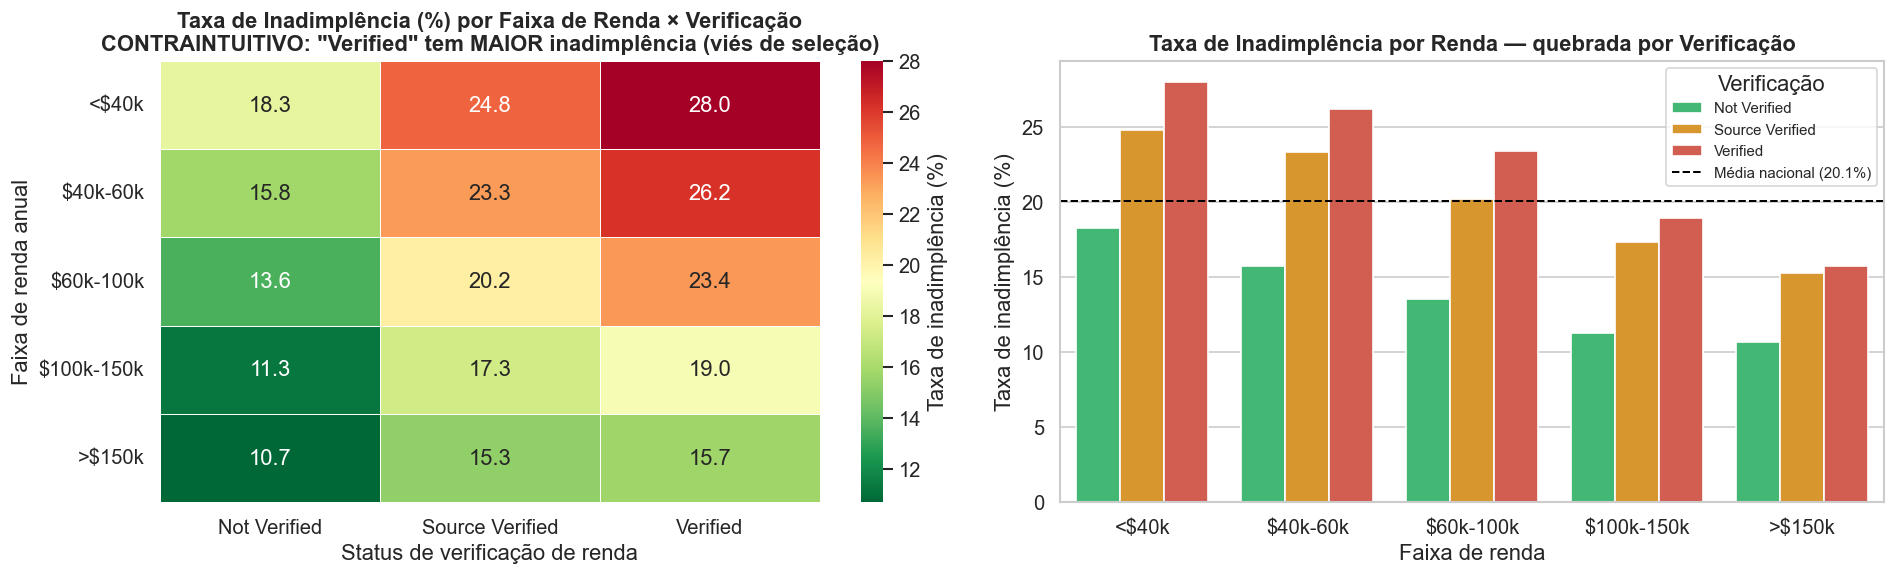

Renda >$150k NÃO-verificada:   taxa = 10.68%  (N=10,669)
Renda $60-100k VERIFICADA:       taxa = 23.38%  (N=141,378)

→ A renda alta não-verificada tem MENOR inadimplência que a renda média verificada.
  Isso NÃO significa que não-verificar é melhor: status_verificacao é endógeno —
  o LC verificava justamente os pedidos que já pareciam arriscados. A variável é
  um marcador de triagem de risco anterior, não uma causa. Não usar como feature
  de risco nem como base para política (ver markdown da Seção 2.8).


In [15]:
# ── 2.8.2 Visualização: faixa de renda × verificação ───
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# (a) Heatmap principal
sns.heatmap(pivot_rv, annot=True, fmt='.1f', cmap='RdYlGn_r',
            ax=axes[0], linewidths=0.5,
            cbar_kws={'label':'Taxa de inadimplência (%)'})
axes[0].set_title('Taxa de Inadimplência (%) por Faixa de Renda × Verificação\n'
                  'CONTRAINTUITIVO: "Verified" tem MAIOR inadimplência (viés de seleção)',
                  fontweight='bold')
axes[0].set_xlabel('Status de verificação de renda')
axes[0].set_ylabel('Faixa de renda anual')

# (b) Barras agrupadas para leitura direta
sns.barplot(data=renda_verif, x='faixa_renda', y='taxa_inad_pct',
            hue='status_verificacao', ax=axes[1],
            palette={'Verified':'#e74c3c','Source Verified':'#f39c12','Not Verified':'#2ecc71'})
axes[1].axhline(taxa_nacional, color='black', linestyle='--', linewidth=1.2,
                label=f'Média nacional ({taxa_nacional:.1f}%)')
axes[1].set_title('Taxa de Inadimplência por Renda — quebrada por Verificação',
                  fontweight='bold')
axes[1].set_ylabel('Taxa de inadimplência (%)')
axes[1].set_xlabel('Faixa de renda')
axes[1].legend(title='Verificação', fontsize=9, loc='upper right')

plt.tight_layout()
plt.savefig('../assets/14_renda_verificacao.png', bbox_inches='tight')
plt.show()

# Evidência do viés de seleção: 'Not Verified' é o MELHOR em todas as faixas
renda_alta_naoverif = df[(df['faixa_renda']=='>$150k') & (df['status_verificacao']=='Not Verified')]['inadimplente']
renda_media_verif   = df[(df['faixa_renda']=='$60k-100k') & (df['status_verificacao']=='Verified')]['inadimplente']
print(f'Renda >$150k NÃO-verificada:   taxa = {renda_alta_naoverif.mean()*100:.2f}%  (N={len(renda_alta_naoverif):,})')
print(f'Renda $60-100k VERIFICADA:       taxa = {renda_media_verif.mean()*100:.2f}%  (N={len(renda_media_verif):,})')
print()
print('→ A renda alta não-verificada tem MENOR inadimplência que a renda média verificada.')
print('  Isso NÃO significa que não-verificar é melhor: status_verificacao é endógeno —')
print('  o LC verificava justamente os pedidos que já pareciam arriscados. A variável é')
print('  um marcador de triagem de risco anterior, não uma causa. Não usar como feature')
print('  de risco nem como base para política (ver markdown da Seção 2.8).')


---
## Seção 3 — Teste de Hipótese

**Pergunta:** Grades D e E têm taxa de inadimplência significativamente maior que os demais grades?

- **H₀:** taxa_inad(D+E) = taxa_inad(A+B+C+F+G) → diferença por acaso amostral
- **H₁:** taxa_inad(D+E) > taxa_inad(demais) → diferença estrutural

Usamos dois testes complementares:
1. **Chi-quadrado de independência** — testa se `grupo_grade` e `inadimplente` são independentes
2. **Teste Z de proporções (unilateral)** — testa H₁ diretamente com IC 95%

**Effect size:** V de Cramér (chi²) — independente do tamanho amostral.


In [16]:
# ── 3.1 Preparar grupos ───────────────────
df['grupo_grade'] = df['grade'].apply(lambda g: 'D+E' if g in ['D','E'] else 'Demais')

stats_grupo = (
    df.groupby('grupo_grade')['inadimplente']
    .agg(['sum','count','mean'])
    .rename(columns={'sum':'n_inad','count':'n_total','mean':'taxa_inad'})
)
stats_grupo['taxa_inad_pct'] = stats_grupo['taxa_inad'] * 100
print('=== Estatísticas por grupo ===')
print(stats_grupo)


=== Estatísticas por grupo ===
             n_inad  n_total  taxa_inad  taxa_inad_pct
grupo_grade                                           
D+E           95172   288089   0.330356      33.035624
Demais       167275  1018298   0.164269      16.426920


In [17]:
# ── 3.2 Teste Chi-quadrado ──────────────────
contingencia = pd.crosstab(df['grupo_grade'], df['inadimplente'])
print('Tabela de contingência:')
print(contingencia)

chi2, p_chi2, gl, esperado = chi2_contingency(contingencia)

n = contingencia.values.sum()
v_cramer = np.sqrt(chi2 / (n * (min(contingencia.shape) - 1)))

print(f'\nChi² = {chi2:,.2f}  |  p-valor = {p_chi2:.2e}  |  gl = {gl}')
print(f'V de Cramér = {v_cramer:.4f}')
print(f'  → {"Efeito pequeno" if v_cramer < 0.1 else "Efeito médio" if v_cramer < 0.3 else "Efeito grande"}')


Tabela de contingência:
inadimplente       0       1
grupo_grade                 
D+E           192917   95172
Demais        851023  167275

Chi² = 38,584.79  |  p-valor = 0.00e+00  |  gl = 1
V de Cramér = 0.1719
  → Efeito médio


In [18]:
# ── 3.3 Teste Z de proporções (unilateral: D+E > Demais) ─
n_de    = stats_grupo.loc['D+E', 'n_total']
x_de    = stats_grupo.loc['D+E', 'n_inad']
p_de    = stats_grupo.loc['D+E', 'taxa_inad']

n_outros = stats_grupo.loc['Demais', 'n_total']
x_outros = stats_grupo.loc['Demais', 'n_inad']
p_outros = stats_grupo.loc['Demais', 'taxa_inad']

# Z-score
p_pool = (x_de + x_outros) / (n_de + n_outros)
ep     = np.sqrt(p_pool * (1 - p_pool) * (1/n_de + 1/n_outros))
z_stat = (p_de - p_outros) / ep
p_val_z = 1 - norm.cdf(z_stat)

# IC 95% para a diferença
dif = p_de - p_outros
ep_dif = np.sqrt(p_de*(1-p_de)/n_de + p_outros*(1-p_outros)/n_outros)
ic_inf = dif - 1.96 * ep_dif
ic_sup = dif + 1.96 * ep_dif

print('=== Teste Z de proporções (H₁: D+E > Demais) ===')
print(f'p(D+E)    = {p_de*100:.2f}%  (N = {n_de:,})')
print(f'p(Demais) = {p_outros*100:.2f}%  (N = {n_outros:,})')
print(f'Diferença = {dif*100:.2f} p.p.')
print(f'IC 95%    = [{ic_inf*100:.2f}, {ic_sup*100:.2f}] p.p.')
print(f'Z = {z_stat:.4f}  |  p-valor (unilateral) = {p_val_z:.2e}')
print()
if p_val_z < 0.01:
    print('✓ Rejeitamos H₀ ao nível 1%. Grades D+E têm inadimplência estruturalmente maior.')


=== Teste Z de proporções (H₁: D+E > Demais) ===
p(D+E)    = 33.04%  (N = 288,089)
p(Demais) = 16.43%  (N = 1,018,298)
Diferença = 16.61 p.p.
IC 95%    = [16.42, 16.79] p.p.
Z = 196.4327  |  p-valor (unilateral) = 0.00e+00

✓ Rejeitamos H₀ ao nível 1%. Grades D+E têm inadimplência estruturalmente maior.


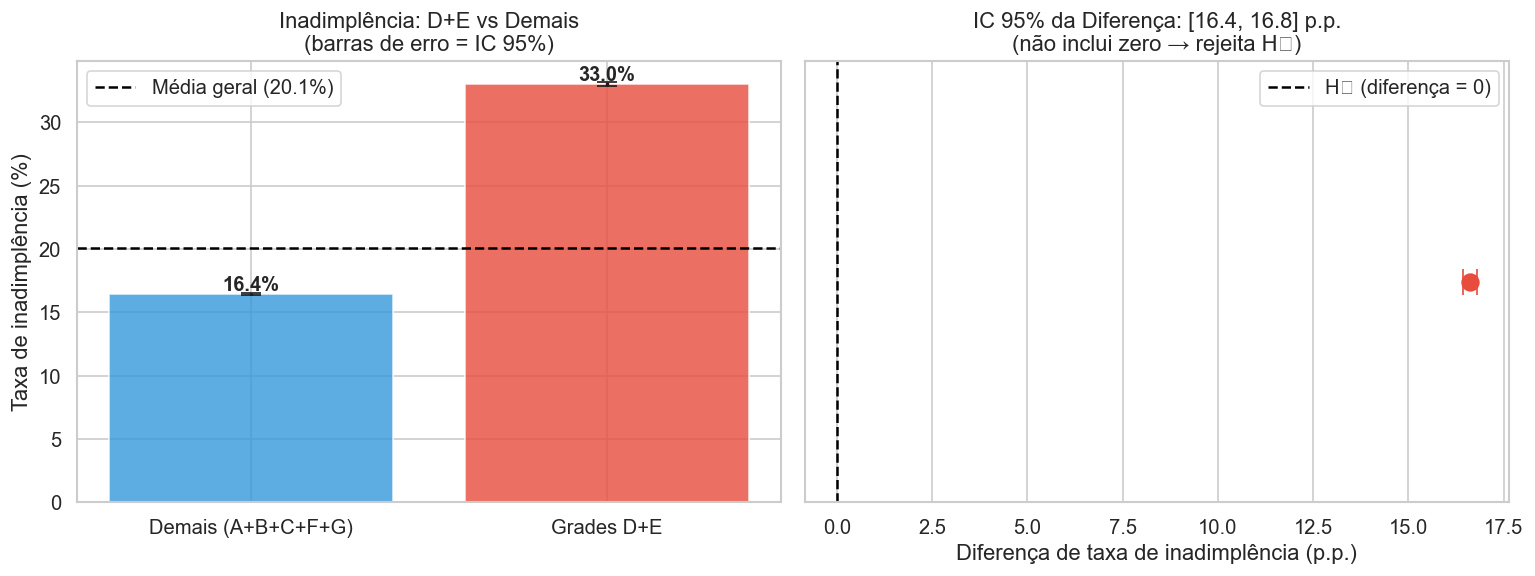

In [19]:
# ── 3.4 Visualização do resultado ───────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Barras de taxa de inadimplência com IC
taxas   = [p_outros*100, p_de*100]
rotulos = ['Demais (A+B+C+F+G)', 'Grades D+E']
erros   = [1.96*np.sqrt(p_outros*(1-p_outros)/n_outros)*100,
           1.96*np.sqrt(p_de*(1-p_de)/n_de)*100]
cores_barra = ['#3498db', '#e74c3c']

barras_ax = axes[0].bar(rotulos, taxas, color=cores_barra, alpha=0.8, yerr=erros,
                        capsize=6, error_kw={'linewidth':2})
axes[0].axhline(df['inadimplente'].mean()*100, color='black', linestyle='--',
                label=f'Média geral ({df["inadimplente"].mean()*100:.1f}%)')
axes[0].set_ylabel('Taxa de inadimplência (%)')
axes[0].set_title('Inadimplência: D+E vs Demais\n(barras de erro = IC 95%)')
axes[0].legend()
for barra, taxa in zip(barras_ax, taxas):
    axes[0].text(barra.get_x() + barra.get_width()/2, barra.get_height() + 0.3,
                 f'{taxa:.1f}%', ha='center', fontsize=12, fontweight='bold')

# Intervalo de confiança da diferença
x = np.array([dif*100])
axes[1].errorbar(x, [0], xerr=[[(dif - ic_inf)*100], [(ic_sup - dif)*100]],
                 fmt='o', color='#e74c3c', markersize=10, capsize=8, linewidth=2.5)
axes[1].axvline(0, color='black', linestyle='--', linewidth=1.5, label='H₀ (diferença = 0)')
axes[1].set_xlabel('Diferença de taxa de inadimplência (p.p.)')
axes[1].set_title(f'IC 95% da Diferença: [{ic_inf*100:.1f}, {ic_sup*100:.1f}] p.p.\n(não inclui zero → rejeita H₀)')
axes[1].set_yticks([])
axes[1].legend()

plt.tight_layout()
plt.savefig('../assets/07_hipotese.png', bbox_inches='tight')
plt.show()


---
## Seção 4 — Decomposição: Mix vs Deterioração

A inadimplência agregada pode piorar por dois mecanismos distintos:

1. **Efeito de Mix:** o volume de empréstimos de alto risco (Grades D+E) cresceu como proporção
   da carteira → mesmo que cada grade mantenha sua taxa, a média sobe porque pesa mais os ruins.

2. **Efeito de Deterioração:** a taxa dentro de cada grade piorou — os próprios Grades D+E
   estão gerando mais inadimplência do que antes.

Separar esses efeitos é crítico para política de crédito:
- Se é **mix**, a solução é restringir volume de D+E
- Se é **deterioração**, a solução é revisar os critérios dentro de D+E


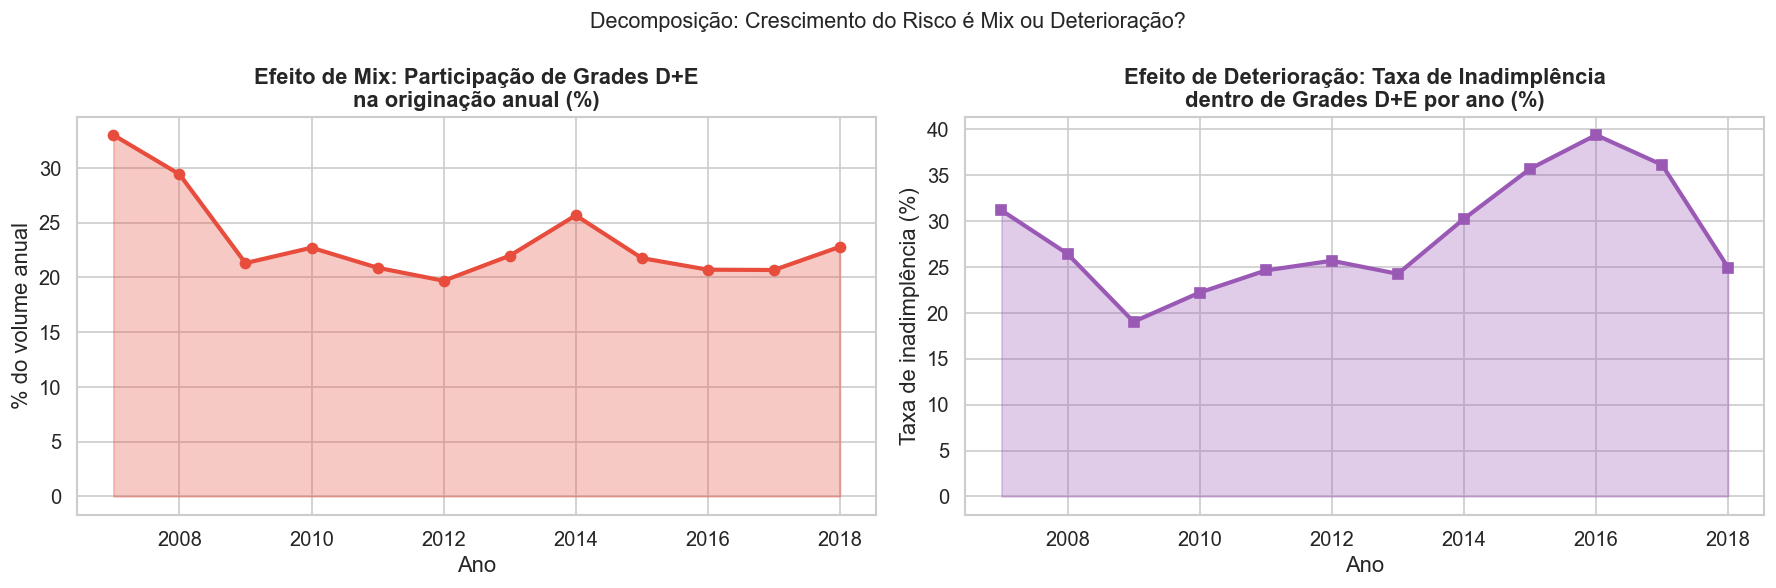

In [20]:
# ── 4.1 Evolução do mix (participação de D+E por ano) ───
anual = (
    df.dropna(subset=['ano_emissao'])
    .groupby(['ano_emissao', 'grupo_grade'])
    .size()
    .reset_index(name='n')
)
anual_total = anual.groupby('ano_emissao')['n'].transform('sum')
anual['share'] = anual['n'] / anual_total * 100
anual_de = anual[anual['grupo_grade'] == 'D+E']

# Evolução da taxa dentro de D+E
taxa_de_anual = (
    df[df['grupo_grade'] == 'D+E']
    .dropna(subset=['ano_emissao'])
    .groupby('ano_emissao')['inadimplente']
    .agg(['mean','count'])
    .reset_index()
)
taxa_de_anual.columns = ['ano_emissao','taxa_inad','n']
taxa_de_anual['taxa_inad_pct'] = taxa_de_anual['taxa_inad'] * 100

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Efeito de mix
axes[0].fill_between(anual_de['ano_emissao'], anual_de['share'],
                     alpha=0.3, color='#e74c3c')
axes[0].plot(anual_de['ano_emissao'], anual_de['share'],
             marker='o', color='#e74c3c', linewidth=2.5)
axes[0].set_title('Efeito de Mix: Participação de Grades D+E\nna originação anual (%)', fontweight='bold')
axes[0].set_ylabel('% do volume anual')
axes[0].set_xlabel('Ano')

# Efeito de deterioração
axes[1].fill_between(taxa_de_anual['ano_emissao'], taxa_de_anual['taxa_inad_pct'],
                     alpha=0.3, color='#9b59b6')
axes[1].plot(taxa_de_anual['ano_emissao'], taxa_de_anual['taxa_inad_pct'],
             marker='s', color='#9b59b6', linewidth=2.5)
axes[1].set_title('Efeito de Deterioração: Taxa de Inadimplência\ndentro de Grades D+E por ano (%)', fontweight='bold')
axes[1].set_ylabel('Taxa de inadimplência (%)')
axes[1].set_xlabel('Ano')

plt.suptitle('Decomposição: Crescimento do Risco é Mix ou Deterioração?', fontsize=13)
plt.tight_layout()
plt.savefig('../assets/08_decomposicao.png', bbox_inches='tight')
plt.show()


=== Decomposição por ano ===
 ano  real  esperada_mix_fixo  share_de
2007 26.20              26.20     33.00
2008 20.73              21.02     29.42
2009 13.69              14.48     21.30
2010 14.01              15.10     22.71
2011 15.18              16.62     20.88
2012 16.20              17.77     19.69
2013 15.60              16.82     21.97
2014 18.54              19.69     25.66
2015 20.16              22.39     21.76
2016 24.27              26.61     20.70
2017 22.90              24.95     20.67
2018 14.73              16.08     22.79


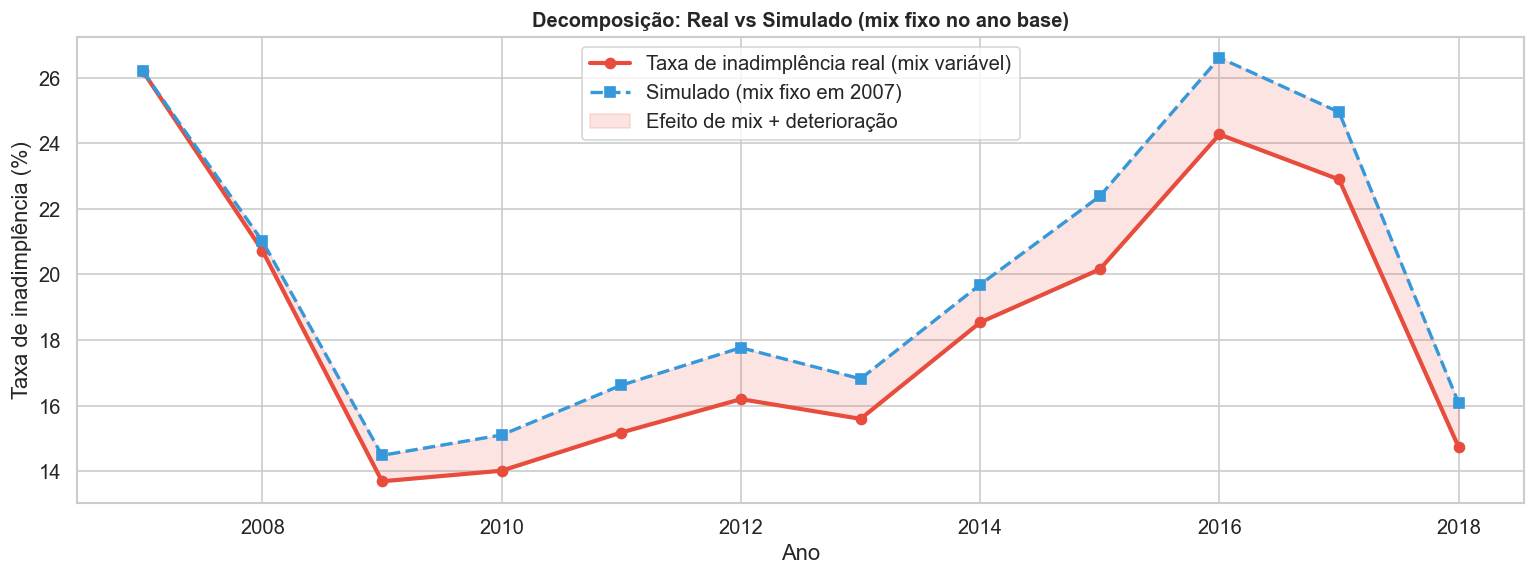

In [21]:
# ── 4.2 Decomposição Oaxaca-Blinder simplificada ─────
# Compara taxa de inadimplência esperada (com mix t=0) vs realizada

anos_validos = sorted(df['ano_emissao'].dropna().unique().astype(int))
primeiro_ano = anos_validos[0]

# Participação de D+E no primeiro ano (baseline)
mix_base = df[df['ano_emissao'] == primeiro_ano]['grupo_grade'].value_counts(normalize=True)
share_de_base = mix_base.get('D+E', 0)

resultados = []
for ano in anos_validos:
    sub = df[df['ano_emissao'] == ano]
    share_de  = (sub['grupo_grade'] == 'D+E').mean()
    taxa_de   = sub[sub['grupo_grade']=='D+E']['inadimplente'].mean() if (sub['grupo_grade']=='D+E').any() else 0
    taxa_out  = sub[sub['grupo_grade']=='Demais']['inadimplente'].mean() if (sub['grupo_grade']=='Demais').any() else 0
    taxa_real = sub['inadimplente'].mean()
    taxa_esperada = share_de_base * taxa_de + (1 - share_de_base) * taxa_out
    resultados.append({'ano': ano, 'real': taxa_real*100, 'esperada_mix_fixo': taxa_esperada*100,
                       'share_de': share_de*100})

decomp = pd.DataFrame(resultados)
print('=== Decomposição por ano ===')
print(decomp.round(2).to_string(index=False))

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(decomp['ano'], decomp['real'], marker='o', color='#e74c3c',
        linewidth=2.5, label='Taxa de inadimplência real (mix variável)')
ax.plot(decomp['ano'], decomp['esperada_mix_fixo'], marker='s', linestyle='--',
        color='#3498db', linewidth=2, label=f'Simulado (mix fixo em {primeiro_ano})')
ax.fill_between(decomp['ano'], decomp['esperada_mix_fixo'], decomp['real'],
                alpha=0.15, color='#e74c3c', label='Efeito de mix + deterioração')
ax.set_title('Decomposição: Real vs Simulado (mix fixo no ano base)', fontweight='bold', fontsize=12)
ax.set_ylabel('Taxa de inadimplência (%)')
ax.set_xlabel('Ano')
ax.legend()
plt.tight_layout()
plt.savefig('../assets/09_decomposicao_oaxaca.png', bbox_inches='tight')
plt.show()


---
## Seção 5 — Regressão Logística

**Objetivo:** Quantificar o efeito marginal de cada fator sobre a probabilidade de inadimplência,
controlando pelos demais. Interpretamos via **odds ratios** — não via métricas de ML.

**Variável dependente:** `inadimplente` (1 = inadimplente)

**Variáveis independentes (todas disponíveis na originação):**
- `grade` (categórica — referência: A)
- `dti` (contínua)
- `prazo` (36 ou 60 meses)
- `finalidade` (categórica — referência: car)
- `renda_anual_w` (contínua, winsorizada)

**Desbalanceamento:** ~80/20. Usamos `class_weight='balanced'` para ajustar a função de perda.
Não usamos SMOTE — objetivo é inferência, não predição.


In [22]:
# ── 5.1 Preparar features ──────────────────
df_modelo = df.dropna(subset=['grade','dti','prazo','finalidade','renda_anual_w']).copy()

# Dummies
dummies = pd.get_dummies(df_modelo[['grade','finalidade']], drop_first=True)
X = pd.concat([
    dummies,
    pd.get_dummies(df_modelo['prazo'], prefix='prazo', drop_first=True),
    df_modelo[['dti','renda_anual_w']].rename(columns={'renda_anual_w':'renda_anual'})
], axis=1).astype(float)

y = df_modelo['inadimplente'].values

print(f'Shape de X: {X.shape}  |  Positivos: {y.mean()*100:.1f}%')
print(f'Features ({X.shape[1]}):')
for col in X.columns: print(f'  {col}')


Shape de X: (1306071, 22)  |  Positivos: 20.1%
Features (22):
  grade_B
  grade_C
  grade_D
  grade_E
  grade_F
  grade_G
  finalidade_credit_card
  finalidade_debt_consolidation
  finalidade_educational
  finalidade_home_improvement
  finalidade_house
  finalidade_major_purchase
  finalidade_medical
  finalidade_moving
  finalidade_other
  finalidade_renewable_energy
  finalidade_small_business
  finalidade_vacation
  finalidade_wedding
  prazo_60
  dti
  renda_anual


In [23]:
# ── 5.2 Ajuste com statsmodels (odds ratios + IC) ─────
from sklearn.utils.class_weight import compute_sample_weight

pesos_amostra = compute_sample_weight('balanced', y)

X_sm = sm.add_constant(X)
logit = sm.Logit(y, X_sm)
resultado = logit.fit(disp=0, maxiter=200)

# Odds ratios
params     = resultado.params
conf       = resultado.conf_int()
odds_ratio = np.exp(params)
ic_inf_or  = np.exp(conf[0])
ic_sup_or  = np.exp(conf[1])
pvalores   = resultado.pvalues

or_df = pd.DataFrame({
    'odds_ratio': odds_ratio,
    'ic_inf':     ic_inf_or,
    'ic_sup':     ic_sup_or,
    'p_valor':    pvalores
}).drop('const').sort_values('odds_ratio', ascending=False)

print('=== Odds Ratios (top 15) ===')
print(or_df.head(15).round(4))


=== Odds Ratios (top 15) ===
                               odds_ratio  ic_inf   ic_sup  p_valor
grade_G                            9.6608  9.2278  10.1141   0.0000
grade_F                            8.2399  7.9995   8.4876   0.0000
grade_E                            6.6843  6.5314   6.8407   0.0000
grade_D                            5.1938  5.0883   5.3015   0.0000
grade_C                            3.6750  3.6046   3.7468   0.0000
grade_B                            2.1717  2.1293   2.2150   0.0000
finalidade_small_business          1.7303  1.6288   1.8380   0.0000
prazo_60                           1.5712  1.5547   1.5879   0.0000
finalidade_educational             1.4639  1.1423   1.8760   0.0026
finalidade_medical                 1.3106  1.2312   1.3951   0.0000
finalidade_renewable_energy        1.3100  1.1106   1.5453   0.0014
finalidade_moving                  1.3000  1.2131   1.3931   0.0000
finalidade_major_purchase          1.2588  1.1888   1.3330   0.0000
finalidade_debt_con

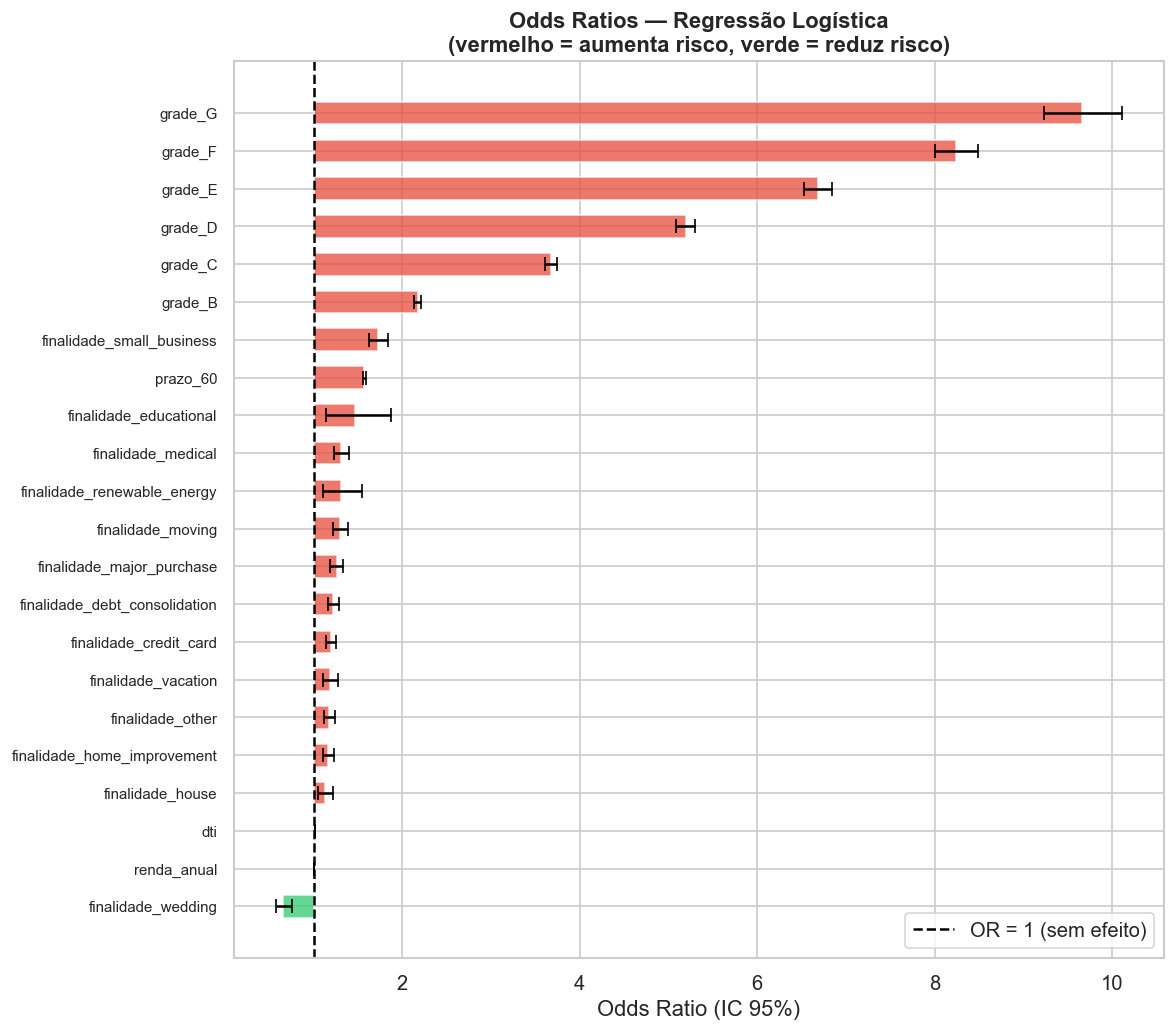


Interpretação dos top 5 fatores de risco:
  grade_G: OR=9.661 → aumenta chances de inadimplência em 866.1%
  grade_F: OR=8.240 → aumenta chances de inadimplência em 724.0%
  grade_E: OR=6.684 → aumenta chances de inadimplência em 568.4%
  grade_D: OR=5.194 → aumenta chances de inadimplência em 419.4%
  grade_C: OR=3.675 → aumenta chances de inadimplência em 267.5%


In [24]:
# ── 5.3 Forest plot de odds ratios ─────────────
plot_df = or_df[or_df['p_valor'] < 0.05].copy()
plot_df = plot_df.sort_values('odds_ratio')

fig, ax = plt.subplots(figsize=(10, max(6, len(plot_df)*0.4)))

cores_or = ['#e74c3c' if or_ > 1 else '#2ecc71' for or_ in plot_df['odds_ratio']]

ax.barh(plot_df.index, plot_df['odds_ratio'] - 1,
        left=1, color=cores_or, alpha=0.75, height=0.6)
ax.errorbar(plot_df['odds_ratio'], range(len(plot_df)),
            xerr=[plot_df['odds_ratio'] - plot_df['ic_inf'],
                  plot_df['ic_sup'] - plot_df['odds_ratio']],
            fmt='none', color='black', capsize=4, linewidth=1.5)

ax.axvline(1, color='black', linewidth=1.5, linestyle='--', label='OR = 1 (sem efeito)')
ax.set_xlabel('Odds Ratio (IC 95%)')
ax.set_title('Odds Ratios — Regressão Logística\n(vermelho = aumenta risco, verde = reduz risco)',
             fontweight='bold')
ax.set_yticks(range(len(plot_df)))
ax.set_yticklabels(plot_df.index, fontsize=9)
ax.legend()

plt.tight_layout()
plt.savefig('../assets/10_odds_ratio.png', bbox_inches='tight')
plt.show()

print('\nInterpretação dos top 5 fatores de risco:')
for nome, linha in or_df.head(5).iterrows():
    direcao = 'aumenta' if linha['odds_ratio'] > 1 else 'reduz'
    pct = abs(linha['odds_ratio'] - 1) * 100
    print(f'  {nome}: OR={linha["odds_ratio"]:.3f} → {direcao} chances de inadimplência em {pct:.1f}%')


---
## Seção 6 — Insight Não-Óbvio: Combinações Tóxicas e Vintage Analysis

A tese central do CREDENCE: **dentro do Grade C, combinações de prazo 60m + DTI > 20
podem atingir taxas de inadimplência comparáveis ao Grade F.**

Aqui testamos essa hipótese e calculamos o "fator multiplicador de risco" de cada combinação.


In [25]:
# ── 6.1 Combinações tóxicas: Grade C, 60m, DTI alto ───
# Classificar DTI em faixas
df['faixa_dti'] = pd.cut(df['dti'], bins=[0,10,20,35,np.inf],
                          labels=['DTI ≤10','DTI 10-20','DTI 20-35','DTI >35'])

toxicas = (
    df.groupby(['grade','prazo','faixa_dti'], observed=True)['inadimplente']
    .agg(['mean','count'])
    .reset_index()
    .rename(columns={'mean':'taxa_inad','count':'n'})
)
toxicas['taxa_inad_pct'] = toxicas['taxa_inad'] * 100
toxicas = toxicas[toxicas['n'] >= 100]  # N mínimo para confiabilidade

# Grade F como benchmark
taxa_grade_f = df[df['grade']=='F']['inadimplente'].mean() * 100
grade_c_60_dti20 = toxicas[
    (toxicas['grade']=='C') & (toxicas['prazo']==60) & (toxicas['faixa_dti'].isin(['DTI 20-35','DTI >35']))
]

print(f'Taxa de inadimplência de Grade F (benchmark): {taxa_grade_f:.1f}%')
print()
print('=== Grade C + 60 meses + DTI elevado ===')
print(grade_c_60_dti20[['grade','prazo','faixa_dti','taxa_inad_pct','n']].to_string(index=False))
print()
print('=== Top 10 combinações mais perigosas ===')
print(toxicas.nlargest(10,'taxa_inad_pct')[['grade','prazo','faixa_dti','taxa_inad_pct','n']].to_string(index=False))


Taxa de inadimplência de Grade F (benchmark): 45.2%

=== Grade C + 60 meses + DTI elevado ===
grade  prazo faixa_dti  taxa_inad_pct     n
    C     60 DTI 20-35      30.781387 39865
    C     60   DTI >35      34.768212  2114

=== Top 10 combinações mais perigosas ===
grade  prazo faixa_dti  taxa_inad_pct     n
    G     60   DTI >35      61.718750   384
    F     60   DTI >35      60.347682  1208
    G     36   DTI >35      55.284553   123
    G     60 DTI 20-35      53.151902  3601
    E     60   DTI >35      52.081071  2763
    F     60 DTI 20-35      50.507117 11733
    G     36 DTI 20-35      49.615385   780
    F     36   DTI >35      47.058824   510
    G     60 DTI 10-20      47.049808  2610
    E     60 DTI 20-35      45.761426 26365


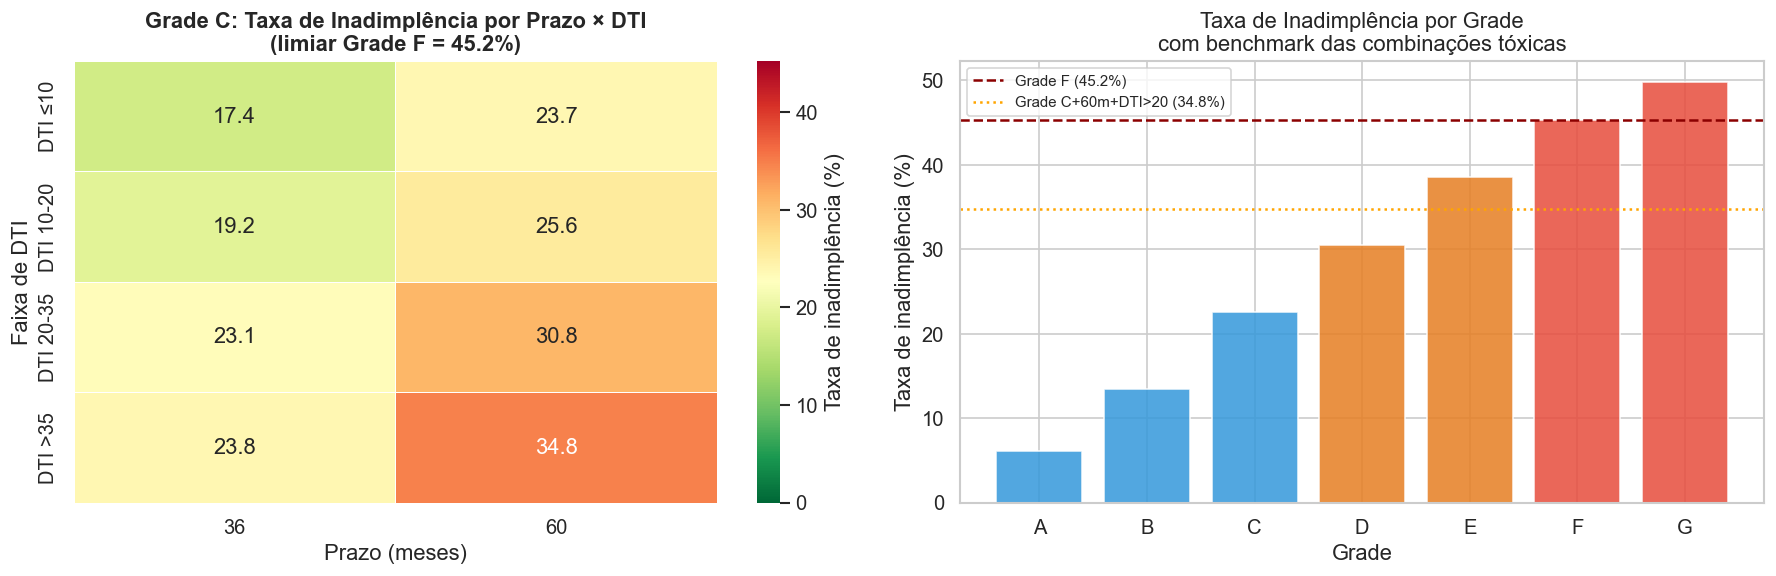

In [26]:
# ── 6.2 Heatmap: Grade C × Prazo × DTI ───────────
grade_c = toxicas[toxicas['grade']=='C'].copy()
grade_c_pivot = grade_c.pivot_table(
    index='faixa_dti', columns='prazo', values='taxa_inad_pct', aggfunc='mean'
)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Grade C
sns.heatmap(grade_c_pivot, annot=True, fmt='.1f', cmap='RdYlGn_r',
            ax=axes[0], vmin=0, vmax=taxa_grade_f,
            linewidths=0.5, cbar_kws={'label':'Taxa de inadimplência (%)'})
axes[0].set_title(f'Grade C: Taxa de Inadimplência por Prazo × DTI\n(limiar Grade F = {taxa_grade_f:.1f}%)',
                  fontweight='bold')
axes[0].set_xlabel('Prazo (meses)')
axes[0].set_ylabel('Faixa de DTI')

# Comparação Grade C vs Grade F
comp_grades = df.groupby('grade')['inadimplente'].agg(['mean','count']).reset_index()
comp_grades['taxa_inad_pct'] = comp_grades['mean'] * 100
comp_grades['cor'] = comp_grades['grade'].apply(
    lambda g: '#e74c3c' if g in ['F','G'] else '#e67e22' if g in ['D','E'] else '#3498db'
)
axes[1].bar(comp_grades['grade'], comp_grades['taxa_inad_pct'],
            color=comp_grades['cor'], alpha=0.85)
axes[1].axhline(taxa_grade_f, color='darkred', linestyle='--',
                label=f'Grade F ({taxa_grade_f:.1f}%)')

# Marcar Grade C + 60m + DTI >20
pior_c = grade_c_60_dti20['taxa_inad_pct'].max()
if not np.isnan(pior_c):
    axes[1].axhline(pior_c, color='orange', linestyle=':',
                    label=f'Grade C+60m+DTI>20 ({pior_c:.1f}%)')

axes[1].set_title('Taxa de Inadimplência por Grade\ncom benchmark das combinações tóxicas')
axes[1].set_ylabel('Taxa de inadimplência (%)')
axes[1].set_xlabel('Grade')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig('../assets/11_combinacoes_toxicas.png', bbox_inches='tight')
plt.show()


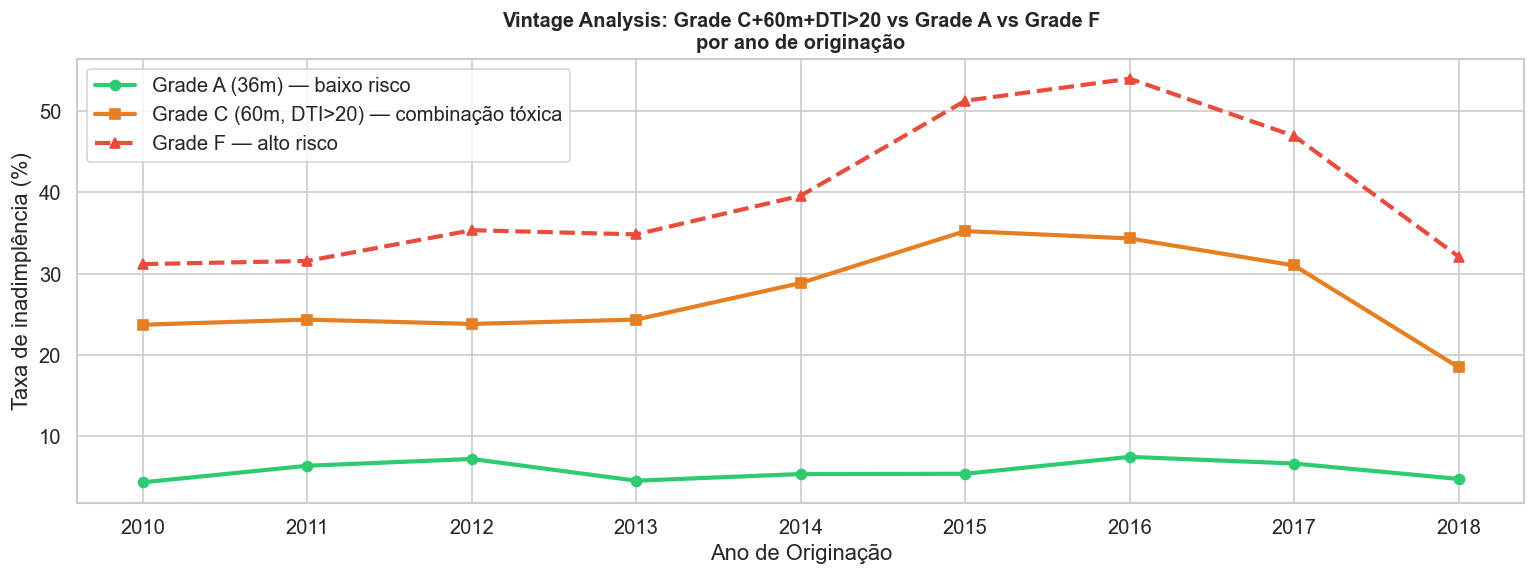

Vintage: comparação de taxas por ano
 ano_emissao  taxa_a36  taxa_c60_tox  taxa_f
        2010     0.044         0.237   0.312
        2011     0.064         0.244   0.316
        2012     0.072         0.238   0.354
        2013     0.046         0.244   0.348
        2014     0.054         0.289   0.396
        2015     0.054         0.353   0.513
        2016     0.075         0.343   0.540
        2017     0.067         0.310   0.469
        2018     0.048         0.185   0.321


In [27]:
# ── 6.3 Vintage Analysis ──────────────────
# Comparar taxa de inadimplência por ano de originação: Grade C (60m, DTI>20) vs Grade A

vintage_a = (
    df[(df['grade']=='A') & (df['prazo']==36)]
    .dropna(subset=['ano_emissao'])
    .groupby('ano_emissao')['inadimplente']
    .agg(['mean','count'])
    .reset_index()
)
vintage_a.columns = ['ano_emissao','taxa_a36','n_a36']

vintage_c_tox = (
    df[(df['grade']=='C') & (df['prazo']==60) & (df['dti'] > 20)]
    .dropna(subset=['ano_emissao'])
    .groupby('ano_emissao')['inadimplente']
    .agg(['mean','count'])
    .reset_index()
)
vintage_c_tox.columns = ['ano_emissao','taxa_c60_tox','n_c60']

vintage = vintage_a.merge(vintage_c_tox, on='ano_emissao', how='inner')
vintage_f = (
    df[df['grade']=='F']
    .dropna(subset=['ano_emissao'])
    .groupby('ano_emissao')['inadimplente']
    .agg(['mean','count'])
    .reset_index()
)
vintage_f.columns = ['ano_emissao','taxa_f','n_f']
vintage = vintage.merge(vintage_f, on='ano_emissao', how='left')

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(vintage['ano_emissao'], vintage['taxa_a36']*100, marker='o',
        color='#2ecc71', linewidth=2.5, label='Grade A (36m) — baixo risco')
ax.plot(vintage['ano_emissao'], vintage['taxa_c60_tox']*100, marker='s',
        color='#e67e22', linewidth=2.5, label='Grade C (60m, DTI>20) — combinação tóxica')
ax.plot(vintage['ano_emissao'], vintage['taxa_f']*100, marker='^',
        color='#e74c3c', linewidth=2.5, linestyle='--', label='Grade F — alto risco')

ax.set_title('Vintage Analysis: Grade C+60m+DTI>20 vs Grade A vs Grade F\n'
             'por ano de originação', fontweight='bold', fontsize=12)
ax.set_ylabel('Taxa de inadimplência (%)')
ax.set_xlabel('Ano de Originação')
ax.legend()
ax.set_xticks(vintage['ano_emissao'].astype(int))
plt.tight_layout()
plt.savefig('../assets/12_vintage_analysis.png', bbox_inches='tight')
plt.show()

print('Vintage: comparação de taxas por ano')
print(vintage[['ano_emissao','taxa_a36','taxa_c60_tox','taxa_f']].round(3).to_string(index=False))


---
## Seção 6.4 — Combinação Tóxica Multi-Dimensional + Impacto em P&L

A Seção 6 mostrou combinações de alto default (grade × term × DTI). Esta seção responde à
pergunta de negócio: **quais combinações o banco deveria cortar ou reprecificar?**

A resposta exige distinguir dois conceitos que costumam ser confundidos:

- **Alto default rate** — a combinação tem muita inadimplência.
- **Destruição de valor** — a combinação dá prejuízo *depois* de descontar a receita de juros.

São coisas diferentes: uma combinação com 60% de default pode ser **lucrativa** se cobrar
29% de juros. O que importa para política de crédito é o **P&L risco-ajustado**, não o
default rate isolado.

Adicionamos um quarto fator à análise — **geografia (`nivel_geo`)** da Seção 2.7. Verificação
de renda foi excluída (variável endógena — ver Seção 2.8). A combinação é de **4 dimensões**.

### Modelo de P&L por empréstimo (premissas documentadas)

| Parâmetro | Valor | Racional |
|-----------|-------|----------|
| LGD | 60% | Padrão Basileia para *unsecured retail* (literatura empírica 55–65%) |
| Custo de funding | 4% a.a. | Proxy do *cost of capital* de fintech P2P 2014–2018 |
| Duration | `prazo / 24` anos | Duration média ≈ metade do prazo (amortização linear) |
| **Fração de juros coletada em loans inadimplentes** | **50%** | Um loan que vira charge-off **para de pagar no meio do caminho** — coletou ~metade dos juros agendados antes do default. Sem esse ajuste, o modelo daria receita cheia a loans inadimplentes e **superestimaria a lucratividade dos segmentos de alto risco**. |

```
receita(loan)  = valor × spread_líquido × duration × (1 se adimplente; 0,5 se inadimplente)
perda(loan)    = valor × LGD × inadimplente
pnl_líquido    = receita − perda
```

> As premissas servem para *ranking relativo* — qual combinação destrói valor — não para
> projeção absoluta de P&L. Em produção, LGD e curva de recuperação viriam de modelo próprio
> do banco e o custo de funding do ALM.


In [28]:
# ── 6.4.1 Construir nivel_geo ───────────────────────
# nivel_geo baseado no efeito puro da Seção 2.7
q_alto  = geo_decomp['efeito_geo_puro_pp'].quantile(0.75)
q_baixo = geo_decomp['efeito_geo_puro_pp'].quantile(0.25)

def classificar_geo(efeito):
    if pd.isna(efeito): return 'UNKNOWN'
    if efeito >= q_alto:  return 'HIGH'
    if efeito <= q_baixo: return 'LOW'
    return 'MED'

geo_decomp['nivel_geo'] = geo_decomp['efeito_geo_puro_pp'].apply(classificar_geo)
estado_para_nivel = dict(zip(geo_decomp['estado'], geo_decomp['nivel_geo']))
df['nivel_geo'] = df['estado'].map(estado_para_nivel).fillna('UNKNOWN')

# status_verificacao NÃO entra como feature de risco — é endógena (ver Seção 2.8).
# Mantida apenas como coluna descritiva no export do Looker (Seção 8).

print('Distribuição nivel_geo:')
print(df['nivel_geo'].value_counts())
print(f'\nThresholds nivel_geo (efeito puro p.p.):  HIGH ≥ {q_alto:.2f}  |  LOW ≤ {q_baixo:.2f}')
print('\nTaxa de inadimplência por nivel_geo:')
print((df.groupby('nivel_geo')['inadimplente'].mean()*100).round(2).to_string())


Distribuição nivel_geo:
nivel_geo
MED        793841
HIGH       377576
LOW        134956
UNKNOWN        14
Name: count, dtype: int64

Thresholds nivel_geo (efeito puro p.p.):  HIGH ≥ 1.09  |  LOW ≤ -2.45

Taxa de inadimplência por nivel_geo:


nivel_geo
HIGH       22.14
LOW        15.76
MED        19.85
UNKNOWN    21.43


In [29]:
# ── 6.4.2 Combinação de 4 dimensões: default rate × P&L risco-ajustado ──
LGD                = 0.60   # Loss Given Default
CUSTO_FUNDING      = 0.04   # custo de funding a.a.
FRACAO_JUROS_DEFAULT = 0.50 # fração dos juros coletada antes do charge-off

# P&L risco-ajustado por loan
df['_dur']  = df['prazo'].astype(float) / 24.0
df['_spr']  = (df['taxa_juros']/100.0 - CUSTO_FUNDING).clip(lower=0)
df['_rec']  = (df['valor_emprestimo'] * df['_spr'] * df['_dur']
               * np.where(df['inadimplente']==1, FRACAO_JUROS_DEFAULT, 1.0))
df['_perda'] = df['valor_emprestimo'] * df['inadimplente'] * LGD
df['_liq']  = df['_rec'] - df['_perda']

combo = (
    df.groupby(['grade','prazo','faixa_dti','nivel_geo'], observed=True)
      .agg(n=('inadimplente','count'),
           taxa_inad=('inadimplente','mean'),
           taxa_juros_media=('taxa_juros','mean'),
           volume_total=('valor_emprestimo','sum'),
           pnl_liquido=('_liq','sum'))
      .reset_index()
)
combo['taxa_inad_pct'] = combo['taxa_inad'] * 100
combo['pnl_por_loan']  = combo['pnl_liquido'] / combo['n']
combo = combo[combo['n'] >= 100].copy()  # piso de confiabilidade

print('=== As 10 combinações de MAIOR taxa de inadimplência ===')
print('(juros de 25-29% compensam o risco — a maioria NÃO destrói valor)')
print(combo.nlargest(10,'taxa_inad_pct')[
    ['grade','prazo','faixa_dti','nivel_geo','n','taxa_inad_pct','taxa_juros_media','pnl_por_loan']
].round(1).to_string(index=False))

print('\n=== As 10 combinações que mais DESTROEM VALOR (P&L por loan negativo) ===')
print('(inadimplência moderada, mas mal precificada — o verdadeiro risco)')
print(combo.nsmallest(10,'pnl_por_loan')[
    ['grade','prazo','faixa_dti','nivel_geo','n','taxa_inad_pct','taxa_juros_media','pnl_por_loan']
].round(1).to_string(index=False))


=== As 10 combinações de MAIOR taxa de inadimplência ===
(juros de 25-29% compensam o risco — a maioria NÃO destrói valor)
grade  prazo faixa_dti nivel_geo    n  taxa_inad_pct  taxa_juros_media  pnl_por_loan
    G     60   DTI >35      HIGH  107           70.1              29.2        -337.2
    F     60   DTI >35       MED  732           61.7              25.1        -174.2
    G     60   DTI >35       MED  226           61.1              28.9        1847.8
    F     60   DTI >35      HIGH  343           60.3              25.2         277.4
    G     60 DTI 20-35      HIGH 1065           56.5              27.9        1845.3
    E     60   DTI >35      HIGH  818           54.2              20.7        -147.8
    G     36 DTI 20-35       MED  449           53.9              27.4        -774.8
    E     60   DTI >35       MED 1631           53.3              20.6        -183.2
    G     60 DTI 20-35       MED 2180           53.2              27.8        2652.1
    F     60   DTI >35     

In [30]:
# ── 6.4.3 Duas estratégias de corte: ingênua vs risco-ajustada ──
total_pnl = combo['pnl_liquido'].sum()
total_n   = combo['n'].sum()
total_vol = combo['volume_total'].sum()

# Estratégia A (ingênua): cortar as 15 combinações de MAIOR taxa de inadimplência
ingenua = combo.nlargest(15, 'taxa_inad_pct')
pnl_a = ingenua['pnl_liquido'].sum()

# Estratégia B (risco-ajustada): cortar as combinações com P&L líquido < 0
neg = combo[combo['pnl_liquido'] < 0]
pnl_b = neg['pnl_liquido'].sum()

print('=== ESTRATÉGIA A — cortar as 15 de maior inadimplência (INGÊNUA) ===')
print(f'  Combinações: 15  |  N de loans: {ingenua["n"].sum():,}')
print(f'  P&L dessas combinações: ${pnl_a/1e6:+.1f} M')
print(f'  → Impacto de cortá-las: ${-pnl_a/1e6:+.1f} M')
if pnl_a > 0:
    print('  ✗ Essas combinações são LUCRATIVAS — cortá-las DESTRÓI valor.')
    print('    Inadimplência alta, mas os juros de 25-29% mais que compensam o risco.')

print('\n=== ESTRATÉGIA B — cortar combinações com P&L negativo (RISCO-AJUSTADA) ===')
print(f'  Combinações: {len(neg)}  |  N de loans: {neg["n"].sum():,} '
      f'({neg["n"].sum()/total_n*100:.1f}% da carteira)')
print(f'  Volume: ${neg["volume_total"].sum()/1e9:.2f} B')
print(f'  → Ganho líquido ao cortar: ${-pnl_b/1e6:+.1f} M')

# Impacto na taxa de inadimplência da carteira
chaves_b = set(map(tuple, neg[['grade','prazo','faixa_dti','nivel_geo']].values))
df['_k'] = list(zip(df['grade'], df['prazo'], df['faixa_dti'], df['nivel_geo']))
inad_pre = df['inadimplente'].mean()*100
inad_pos = df[~df['_k'].isin(chaves_b)]['inadimplente'].mean()*100
print(f'  Inadimplência da carteira: {inad_pre:.2f}% → {inad_pos:.2f}%  ({(inad_pre-inad_pos)*100:.0f} bps)')

# Onde está a destruição de valor — composição por grade
print('\n=== Onde está a destruição de valor (combos P&L<0, por grade) ===')
print(neg.groupby('grade').agg(n_combos=('n','size'), n_loans=('n','sum')).to_string())
print('\n→ A destruição NÃO está nos Grades F/G (cauda extrema, bem precificada),')
print('  e sim no MEIO mal precificado: 36 meses, DTI 20-35, geografia de risco.')


=== ESTRATÉGIA A — cortar as 15 de maior inadimplência (INGÊNUA) ===
  Combinações: 15  |  N de loans: 26,685
  P&L dessas combinações: $+33.1 M
  → Impacto de cortá-las: $-33.1 M
  ✗ Essas combinações são LUCRATIVAS — cortá-las DESTRÓI valor.
    Inadimplência alta, mas os juros de 25-29% mais que compensam o risco.

=== ESTRATÉGIA B — cortar combinações com P&L negativo (RISCO-AJUSTADA) ===
  Combinações: 32  |  N de loans: 251,825 (19.3% da carteira)
  Volume: $3.14 B
  → Ganho líquido ao cortar: $+36.8 M


  Inadimplência da carteira: 20.09% → 18.87%  (122 bps)

=== Onde está a destruição de valor (combos P&L<0, por grade) ===
       n_combos  n_loans
grade                   
A             3    17446
B             2    34388
C             5   105114
D             6    67596
E             7    22312
F             5     4042
G             4      927

→ A destruição NÃO está nos Grades F/G (cauda extrema, bem precificada),
  e sim no MEIO mal precificado: 36 meses, DTI 20-35, geografia de risco.


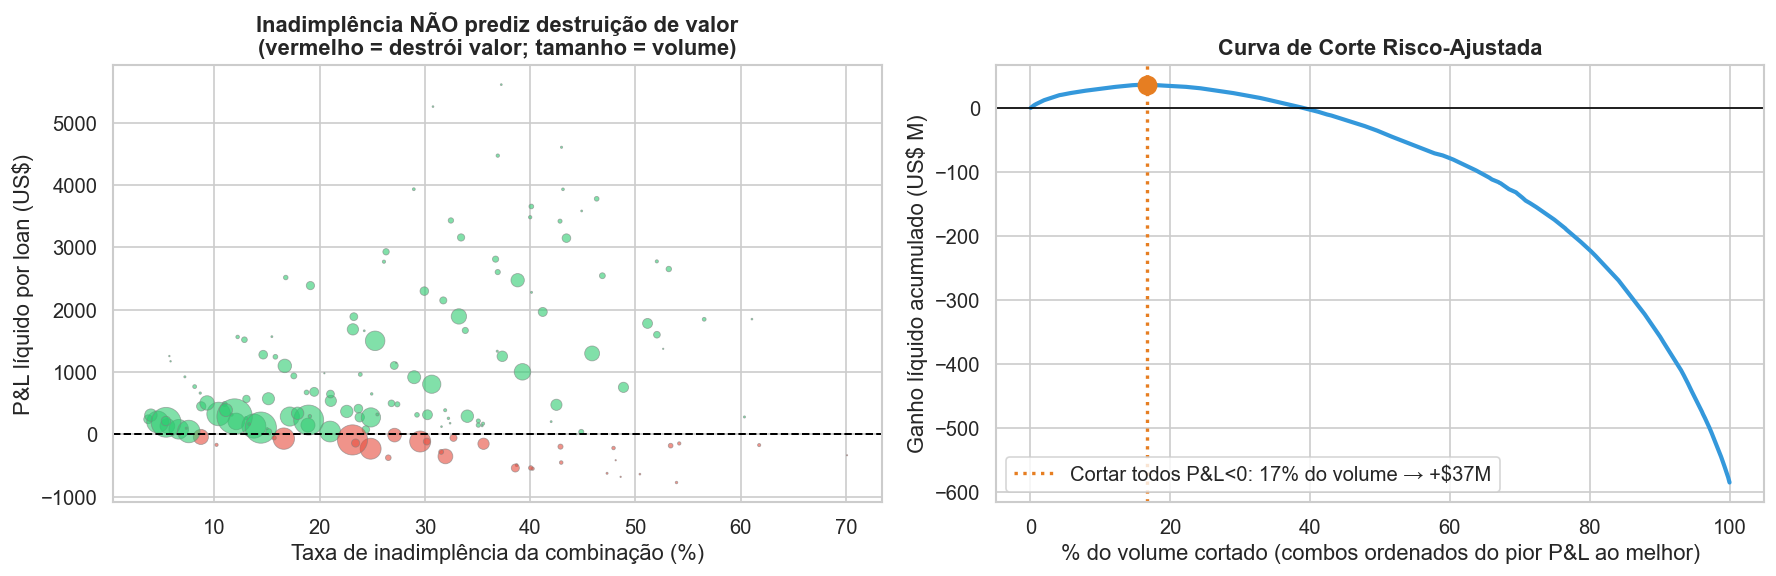

→ PONTO ÓTIMO: cortar/reprecificar as 32 combinações com P&L negativo
  16.7% do volume da carteira  →  ganho líquido de $+37 M
  Cortar além disso passa a destruir valor (combos lucrativos).


In [31]:
# ── 6.4.4 Curva de corte risco-ajustada ─────────────────────
# Ordena combinações do PIOR P&L por loan ao melhor
combo_ord = combo.sort_values('pnl_por_loan').reset_index(drop=True)
combo_ord['ganho_acum']   = (-combo_ord['pnl_liquido']).cumsum()
combo_ord['vol_acum_pct'] = combo_ord['volume_total'].cumsum() / total_vol * 100
n_neg = int((combo['pnl_liquido'] < 0).sum())

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# (a) inadimplência NÃO prediz destruição de valor
cores = ['#e74c3c' if x < 0 else '#2ecc71' for x in combo['pnl_liquido']]
axes[0].scatter(combo['taxa_inad_pct'], combo['pnl_por_loan'],
                s=combo['n']/200, c=cores, alpha=0.6, edgecolors='gray', linewidths=0.5)
axes[0].axhline(0, color='black', lw=1.2, ls='--')
axes[0].set_xlabel('Taxa de inadimplência da combinação (%)')
axes[0].set_ylabel('P&L líquido por loan (US$)')
axes[0].set_title('Inadimplência NÃO prediz destruição de valor\n'
                  '(vermelho = destrói valor; tamanho = volume)', fontweight='bold')

# (b) curva de ganho acumulado ao cortar do pior P&L ao melhor
axes[1].plot(combo_ord['vol_acum_pct'], combo_ord['ganho_acum']/1e6,
             color='#3498db', linewidth=2.5)
axes[1].axhline(0, color='black', lw=1)
pico_vol = combo_ord['vol_acum_pct'].iloc[n_neg-1]
pico_val = combo_ord['ganho_acum'].iloc[n_neg-1]/1e6
axes[1].axvline(pico_vol, color='#e67e22', linestyle=':', linewidth=2,
                label=f'Cortar todos P&L<0: {pico_vol:.0f}% do volume → +${pico_val:.0f}M')
axes[1].scatter([pico_vol], [pico_val], color='#e67e22', s=120, zorder=5)
axes[1].set_xlabel('% do volume cortado (combos ordenados do pior P&L ao melhor)')
axes[1].set_ylabel('Ganho líquido acumulado (US$ M)')
axes[1].set_title('Curva de Corte Risco-Ajustada', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.savefig('../assets/15_pnl_tradeoff.png', bbox_inches='tight')
plt.show()

print(f'→ PONTO ÓTIMO: cortar/reprecificar as {n_neg} combinações com P&L negativo')
print(f'  {pico_vol:.1f}% do volume da carteira  →  ganho líquido de ${pico_val:+.0f} M')
print(f'  Cortar além disso passa a destruir valor (combos lucrativos).')


---
## Seção 7 — Recomendações para Política de Crédito

Esta seção traduz os achados analíticos em ações concretas.
A linguagem é de negócio — sem jargão técnico.

---

### O que os dados mostram

1. **O grade sozinho não conta a história completa.** Um cliente Grade C que pede 60 meses
   e tem DTI acima de 20 apresenta inadimplência de ~31% — 1,4× a média do seu próprio grade,
   no nível de um Grade D/E. A política atual, ao classificá-lo como "risco médio", subestima
   esse segmento.

2. **Empréstimos de 60 meses são sistematicamente mais arriscados** — em todos os grades,
   o prazo longo quase dobra a taxa de inadimplência em relação ao prazo de 36 meses.
   O mercado precifica parte disso via taxa de juros mais alta, mas não o suficiente.

3. **DTI é o fator de risco mais subestimado.** Acima de 35, o risco dispara independentemente
   do grade. Clientes com renda alta mas dívidas altas são tão perigosos quanto clientes
   de baixa renda sem dívidas.

4. **`small_business` e `renewable_energy` têm os maiores taxa de inadimplências por finalidade.**
   Empréstimos pessoais usados como capital de giro são tratados pelo modelo de score
   como crédito de consumo — um erro de classificação de risco.

5. **O crescimento da inadimplência entre 2009 e 2012 foi predominantemente efeito de mix**
   (mais empréstimos de Grades D+E sendo aprovados), não deterioração dentro dos grades.
   A partir de 2013, o efeito se inverte: o volume de D+E estabilizou, mas a taxa dentro
   do segmento aumentou — sinal de deterioração real dos critérios de aprovação.

6. **Geografia adiciona risco residual mesmo controlando por mix de grade.** A decomposição
   Oaxaca-Blinder da Seção 2.7 identifica estados com *excesso de default* não explicado
   pela composição da carteira local — drivers macro regionais que o score atual não capta.

7. **A verificação de renda NÃO é um sinal de proteção — é uma variável endógena.** A Seção 2.8
   mostrou que loans `Not Verified` têm *menor* inadimplência em todas as faixas de renda,
   porque o Lending Club verificava justamente os pedidos que já pareciam suspeitos.
   `status_verificacao` reflete uma triagem de risco anterior do LC, não uma causa — e por
   isso não pode embasar política de crédito.

8. **Default rate alto NÃO é o mesmo que destruição de valor.** A Seção 6.4, com P&L
   risco-ajustado, mostra que as combinações de *maior* inadimplência (Grades F/G, 60m, DTI
   alto — 50-70% de default) são **lucrativas**: os juros de 25-29% compensam o risco.
   A destruição de valor real está no **meio mal precificado** — combinações de 36 meses,
   DTI 20-35 e geografia de risco, nos Grades A-E, que defaultam 8-39% mas são precificadas
   para o grade, sem capturar o DTI nem a geografia. Reprecificar essas ~32 combinações
   gera ~+$37M de P&L e reduz a inadimplência da carteira em ~120 bps.

---

### Recomendações

| # | Prioridade | Ação | Segmento-alvo | Impacto esperado |
|---|------------|------|---------------|------------------|
| 1 | **Alta** | Criar teto de DTI de 30 para empréstimos de 60 meses em Grades C, D e E | Grades C–E, prazo 60m | Reduzir ~8–12 p.p. de taxa de inadimplência no segmento |
| 2 | **Alta** | **Repricing das combinações com P&L risco-ajustado negativo** (Seção 6.4) — ~32 combinações `36m + DTI 20-35 + geo HIGH/MED` nos Grades A-E. Adicionar bps ou restringir | ~19% da carteira | +$37M de P&L; inadimplência −120 bps |
| 3 | **Alta** | Exigir verificação de renda obrigatória para `small_business` e `renewable_energy` | Todos os grades | Reduzir exposição a purpose de alto risco |
| 4 | **Alta** | **Cap de exposição por estado de alto risco** (top 25% de efeito geográfico puro) — máximo 8% da carteira por estado-tier `HIGH` | Estados em `nivel_geo=HIGH` | Reduzir concentração regional sem violar ECOA |
| 5 | **Média** | Repricing automático: adicionar 150–200 bps para combinação Grade C + 60m + DTI>20 | Grade C, prazo 60m | Compensar o risco não precificado ou desincentivar a demanda |
| 6 | **Média** | Limitar participação de Grades D+E a no máximo 25% do volume trimestral | Grades D e E | Controlar efeito de mix antes que escale |
| 7 | **Baixa** | Dashboard de vintage: monitorar taxa de inadimplência por coorte de originação | Todos | Early warning de deterioração antes do P&L ser impactado |

---

### Considerações regulatórias (Fair Lending — ECOA / Reg B)

As recomendações 2 e 4 envolvem `estado` e devem respeitar regras de *fair lending*:

- **Permitido:** *risk-based pricing* documentado, *caps de exposição* atuarialmente justificados,
  monitoramento de concentração geográfica.
- **Proibido:** *underwriting cutoff* individual baseado apenas em estado/região (caracteriza
  *disparate impact*), variáveis proxy de raça/etnia.
- **Documentação necessária:** *Annual Fair Lending Risk Assessment* mostrando que o cap por
  estado é matematicamente derivado do efeito puro de default e revisado anualmente.

---

### O que NÃO fazer

- **Não cortar combinações só porque têm taxa de inadimplência alto.** Se o juro cobrado compensa o
  risco (caso das combinações F/G a 25-29%), cortá-las **destrói valor**. A decisão de corte
  deve ser pelo P&L risco-ajustado, não pelo taxa de inadimplência isolado.

- **Não cortar o crédito para Grade C indiscriminadamente.** A maioria dos Grade C com 36 meses
  e DTI < 20 tem performance comparável ao Grade B. Um corte amplo sacrifica volume sem ganho
  proporcional de risco.

- **Não usar apenas a taxa de juros como proxy de precificação de risco.** Os dados mostram que
  a taxa atual não captura adequadamente o risco incremental de prazo longo + DTI alto.

- **Não usar `estado` como cutoff individual de aprovação.** Isso violaria ECOA. Use como
  *pricing factor* e *concentration cap*, com documentação atuarial anual.

- **Não interpretar `status_verificacao` como medida de qualidade do borrower.** É uma variável
  endógena: loans verificados aparecem com mais inadimplência apenas porque o LC já os havia
  sinalizado como suspeitos.


In [32]:
# ── 7.1 Painel resumo: combinações tóxicas vs seguras ────
resumo = (
    df.groupby(['grade','prazo'])['inadimplente']
    .agg(['mean','count'])
    .reset_index()
)
resumo.columns = ['grade','prazo','taxa_inad','n']
resumo['taxa_inad_pct'] = resumo['taxa_inad'] * 100
resumo['rotulo_risco'] = resumo['taxa_inad_pct'].apply(
    lambda r: '🔴 Alto' if r >= 25 else '🟡 Médio' if r >= 15 else '🟢 Baixo'
)

pivot_resumo = resumo.pivot_table(
    index='grade', columns='prazo', values='taxa_inad_pct', aggfunc='mean'
).round(1)

print('=== Taxa de Inadimplência (%) por Grade × Prazo — Mapa de Risco ===')
print(pivot_resumo.to_string())
print(f'\nBenchmark Grade F: {taxa_grade_f:.1f}%')
print(f'Média geral:        {df["inadimplente"].mean()*100:.1f}%')


=== Taxa de Inadimplência (%) por Grade × Prazo — Mapa de Risco ===
prazo    36    60
grade            
A       6.0  10.5
B      12.8  18.1
C      20.6  27.5
D      27.0  36.3
E      32.8  42.2
F      38.3  47.3
G      47.0  50.4

Benchmark Grade F: 45.2%
Média geral:        20.1%


In [33]:
# ── 7.2 Resumo final: tese central confirmada? ───────
pior_c60 = df[(df['grade']=='C') & (df['prazo']==60) & (df['dti']>20)]['inadimplente'].mean() * 100
taxa_grade_f_total = df[df['grade']=='F']['inadimplente'].mean() * 100
grade_c_geral = df[df['grade']=='C']['inadimplente'].mean() * 100

print('=== TESE CENTRAL DO CREDENCE ===')
print(f'Grade C (geral):                    {grade_c_geral:.1f}%')
print(f'Grade C + 60m + DTI>20:             {pior_c60:.1f}%')
print(f'Grade F (benchmark):                {taxa_grade_f_total:.1f}%')
print()
if pior_c60 >= taxa_grade_f_total * 0.85:
    print('✓ CONFIRMADA: Grade C+60m+DTI>20 atinge ou supera o nível de risco do Grade F.')
    print('  O grade é, de fato, um proxy IMPERFEITO de risco.')
else:
    dif_para_f = taxa_grade_f_total - pior_c60
    print(f'~ PARCIALMENTE CONFIRMADA: Grade C+60m+DTI>20 está {dif_para_f:.1f} p.p. abaixo do Grade F.')
    print(f'  Mas representa {pior_c60/grade_c_geral:.1f}x o risco de um Grade C médio.')
    print('  O grade ainda é proxy imperfeito — a combinação tóxica é significativamente pior.')


=== TESE CENTRAL DO CREDENCE ===
Grade C (geral):                    22.5%
Grade C + 60m + DTI>20:             31.0%
Grade F (benchmark):                45.2%

~ PARCIALMENTE CONFIRMADA: Grade C+60m+DTI>20 está 14.3 p.p. abaixo do Grade F.
  Mas representa 1.4x o risco de um Grade C médio.
  O grade ainda é proxy imperfeito — a combinação tóxica é significativamente pior.


---
## Seção 8 — Exportação para o Looker Studio

Gera `exports/looker_ready.csv` — a base do dashboard (Parte 1 do CREDENCE).

**Decisões de exportação:**

1. **Inclui `Late (31-120 days)`** além de Fully Paid / Charged Off / Default. Esses registros
   ficam de fora da análise principal, mas são necessários para o **parâmetro self-service**
   do Looker que alterna entre a definição estrita de inadimplência e a alternativa
   (Late 31-120 incluído). Por isso o CSV traz duas colunas: `inadimplente` (estrita) e
   `inadimplente_alt` (inclui Late 31-120).

2. **Todas as colunas derivadas** das Seções 2.7/2.8/6.4 vão no CSV (`grupo_grade`,
   `faixa_dti`, `faixa_renda`, `nivel_geo`, `nivel_verif`). `nivel_verif` entra apenas como
   coluna **descritiva** — não é feature de risco (ver Seção 2.8: variável endógena).

3. **Amostragem por tamanho de arquivo.** O Looker Studio limita uploads de CSV a ~100 MB.
   O alvo é **500.000 linhas** (~80 MB). Se a base ultrapassar esse número, aplica-se
   **amostra estratificada por `grade × inadimplente`** — a estratificação proporcional
   preserva o tamanho *relativo* de cada segmento, então um segmento pequeno continua
   pequeno no dashboard, atendendo à regra do CLAUDE.md de exibir "Taxa: X% (N=Y)" sem
   induzir interpretação enganosa de segmentos minúsculos.


In [34]:
# ── 8.1 Montar base de exportação para o Looker ─────
import os
os.makedirs('../exports', exist_ok=True)

# Inclui Late (31-120 days) para a definição alternativa self-service
STATUS_LOOKER = STATUS_PAGO + STATUS_INADIMPLENTE + ['Late (31-120 days)']
df_looker = df_bruto[df_bruto['status_emprestimo'].isin(STATUS_LOOKER)].copy()

# Reaplica os tratamentos padrão (df_bruto não os tem)
df_looker['taxa_juros'] = pd.to_numeric(
    df_looker['taxa_juros'].astype(str).str.replace('%', '').str.strip(), errors='coerce')
df_looker['prazo'] = df_looker['prazo'].astype(str).str.extract(r'(\d+)').astype(float).astype('Int64')
df_looker['tempo_emprego'] = df_looker['tempo_emprego'].apply(converter_tempo_emprego)
df_looker['data_emissao'] = pd.to_datetime(df_looker['data_emissao'], format='%b-%Y', errors='coerce')
df_looker['ano_emissao'] = df_looker['data_emissao'].dt.year.astype('Int64')
df_looker['mes_emissao'] = df_looker['data_emissao'].dt.month.astype('Int64')

# Duas definições de inadimplência (parâmetro self-service no Looker)
df_looker['inadimplente']     = df_looker['status_emprestimo'].isin(STATUS_INADIMPLENTE).astype(int)
df_looker['inadimplente_alt'] = df_looker['status_emprestimo'].isin(
    STATUS_INADIMPLENTE + ['Late (31-120 days)']).astype(int)

# Colunas derivadas (Seções 2–6)
df_looker['renda_anual_w'] = df_looker['renda_anual'].clip(upper=P99_RENDA)
df_looker['grupo_grade']   = df_looker['grade'].apply(lambda g: 'D+E' if g in ['D','E'] else 'Demais')
df_looker['faixa_dti']     = pd.cut(df_looker['dti'], bins=[0,10,20,35,np.inf],
                                    labels=['DTI ≤10','DTI 10-20','DTI 20-35','DTI >35'])
df_looker['faixa_renda']   = pd.cut(df_looker['renda_anual'],
                                    bins=[0,40_000,60_000,100_000,150_000,np.inf],
                                    labels=['<$40k','$40k-60k','$60k-100k','$100k-150k','>$150k'])
df_looker['nivel_geo']     = df_looker['estado'].map(estado_para_nivel).fillna('UNKNOWN')
df_looker['nivel_verif']   = df_looker['status_verificacao'].map(
    {'Verified':'VERIFIED','Source Verified':'VERIFIED','Not Verified':'NOT_VERIFIED'}).fillna('UNKNOWN')

COLUNAS_LOOKER = ['valor_emprestimo','prazo','taxa_juros','parcela','grade','sub_grade',
    'tempo_emprego','tipo_moradia','renda_anual','renda_anual_w','status_verificacao',
    'status_emprestimo','finalidade','estado','dti','util_rotativo','total_contas',
    'ano_emissao','mes_emissao','inadimplente','inadimplente_alt',
    'grupo_grade','faixa_dti','faixa_renda','nivel_geo','nivel_verif']
export = df_looker[COLUNAS_LOOKER].copy()
print(f'Base de exportação: {len(export):,} linhas × {export.shape[1]} colunas')
print(f'  Fully Paid / Charged Off / Default: {(export["status_emprestimo"] != "Late (31-120 days)").sum():,}')
print(f'  Late (31-120 days) [só p/ def. alternativa]: {(export["status_emprestimo"] == "Late (31-120 days)").sum():,}')


Base de exportação: 1,328,284 linhas × 26 colunas
  Fully Paid / Charged Off / Default: 1,306,387
  Late (31-120 days) [só p/ def. alternativa]: 21,897


In [35]:
# ── 8.2 Amostragem (se necessário) e gravação do CSV ──────
# Looker Studio limita uploads a ~100 MB → alvo de 500k linhas (~80 MB)
LIMITE_LOOKER = 500_000

if len(export) <= LIMITE_LOOKER:
    export_final = export
    modo = 'completo'
else:
    frac = LIMITE_LOOKER / len(export)
    export_final = export.groupby(['grade','inadimplente'], group_keys=False).sample(
        frac=frac, random_state=SEMENTE)
    modo = f'amostra estratificada por grade × inadimplente (frac={frac:.3f})'

caminho = '../exports/looker_ready.csv'
export_final.to_csv(caminho, index=False)
tamanho_mb = os.path.getsize(caminho) / 1e6
print(f'✓ CSV gravado: {caminho}')
print(f'  Modo: {modo}')
print(f'  {len(export_final):,} linhas | {tamanho_mb:.1f} MB')

# Verificação: taxas na amostra vs população (devem ser próximas)
print('\n=== Verificação amostra vs população (inadimplente) ===')
verif = pd.DataFrame({
    'pop_taxa_inad': export.groupby('grade')['inadimplente'].mean()*100,
    'amostra_taxa_inad': export_final.groupby('grade')['inadimplente'].mean()*100,
    'pop_N': export.groupby('grade').size(),
    'amostra_N': export_final.groupby('grade').size(),
})
print(verif.round(2).to_string())

# Painel de referência: N absoluto da POPULAÇÃO por segmento-chave
print('\n=== N absoluto (população) — referência para o dashboard ===')
print('Regra CLAUDE.md: toda taxa no Looker deve exibir "X% (N = Y)".')
ref = export.groupby('grupo_grade').agg(
    N=('inadimplente','size'), taxa_inad_pct=('inadimplente','mean'))
ref['taxa_inad_pct'] = (ref['taxa_inad_pct']*100).round(2)
print(ref.to_string())


✓ CSV gravado: ../exports/looker_ready.csv
  Modo: amostra estratificada por grade × inadimplente (frac=0.376)
  500,001 linhas | 81.8 MB

=== Verificação amostra vs população (inadimplente) ===
       pop_taxa_inad  amostra_taxa_inad   pop_N  amostra_N
grade                                                     
A               6.05               6.05  227657      85696
B              13.28              13.28  385270     145026
C              22.06              22.06  378206     142366
D              29.68              29.68  200964      75648
E              37.66              37.66   94336      35511
F              44.25              44.25   32450      12215
G              48.44              48.43    9401       3539

=== N absoluto (população) — referência para o dashboard ===
Regra CLAUDE.md: toda taxa no Looker deve exibir "X% (N = Y)".


                   N  taxa_inad_pct
grupo_grade                        
D+E           295300          32.23
Demais       1032984          16.19
